In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 8
fig_height = 6
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'RDpccml0LWFpLWNvdXJzZVxtb2R1bGVz'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

C:\Users\SIJUKSWAMY\AppData\Local\Temp\ipykernel_16592\1205352806.py:25: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats(fig_format)


{"C:\\Users\\SIJUKSWAMY\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1722958352.0, "C:\\Users\\SIJUKSWAMY\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1722958352.0, "C:\\Users\\SIJUKSWAMY\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1722958352.0, "C:\\Users\\SIJUKSWAMY\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1722958350.0, "C:\\Users\\SIJUKSWAMY\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1722958350.0, "C:\\Users\\SIJUKSWAMY\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1722958350.0, "C:\\Users\\SIJUKSWAMY\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1722958350.0, "C:\\Users\\SIJUKSWAMY\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1722958350.0, "C:\\Users\\SIJUKSWAMY\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1722958350.0, "C:\\Users\\SI

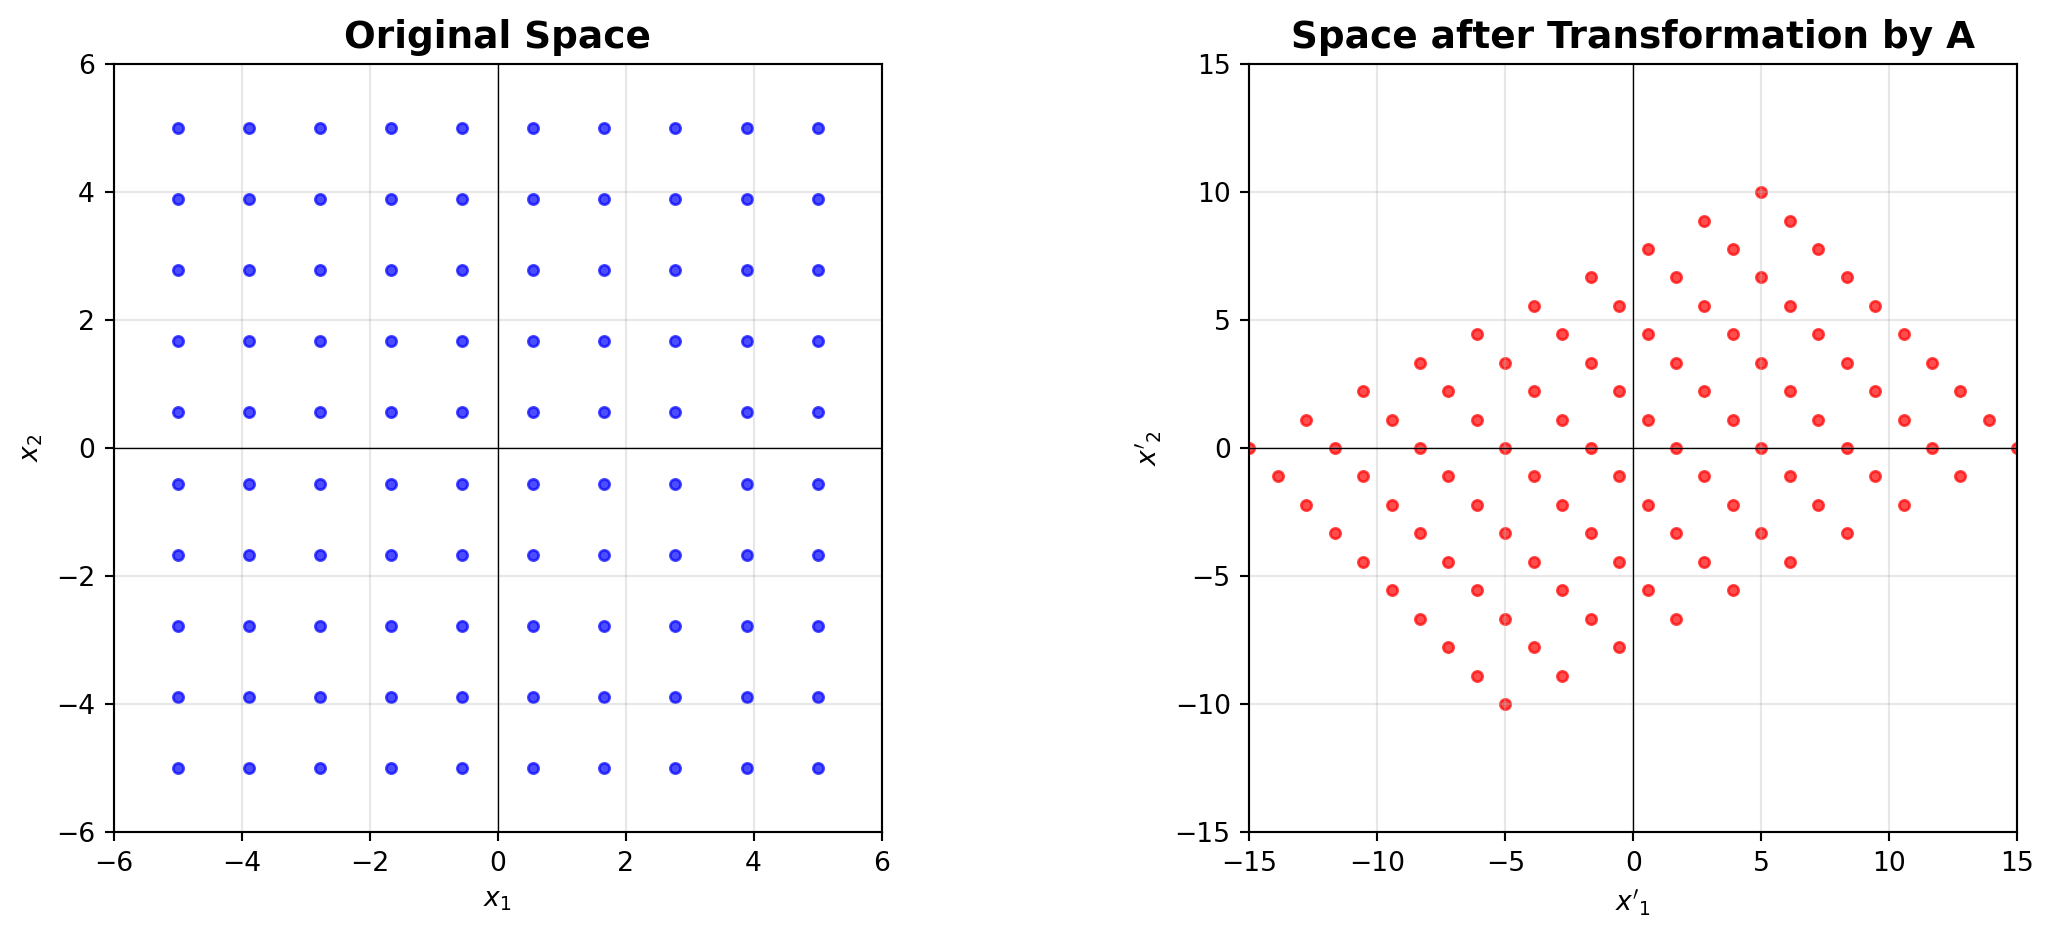

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Create a grid of points (our original space)
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
X, Y = np.meshgrid(x, y)
points = np.vstack([X.flatten(), Y.flatten()])

# Our Transformation Matrix A
A = np.array([[2, -1], 
              [1,  1]])

# Apply the transformation
transformed_points = A @ points

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(points[0], points[1], c='blue', s=15, alpha=0.7)
ax1.set_title("Original Space", fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.axvline(0, color='black', linewidth=0.5)
ax1.set_xlim(-6, 6)
ax1.set_ylim(-6, 6)
ax1.set_aspect('equal')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')

ax2.scatter(transformed_points[0], transformed_points[1], c='red', s=15, alpha=0.7)
ax2.set_title("Space after Transformation by A", fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.axvline(0, color='black', linewidth=0.5)
ax2.set_xlim(-15, 15)
ax2.set_ylim(-15, 15)
ax2.set_aspect('equal')
ax2.set_xlabel("$x'_1$")
ax2.set_ylabel("$x'_2$")

plt.tight_layout()
plt.show()

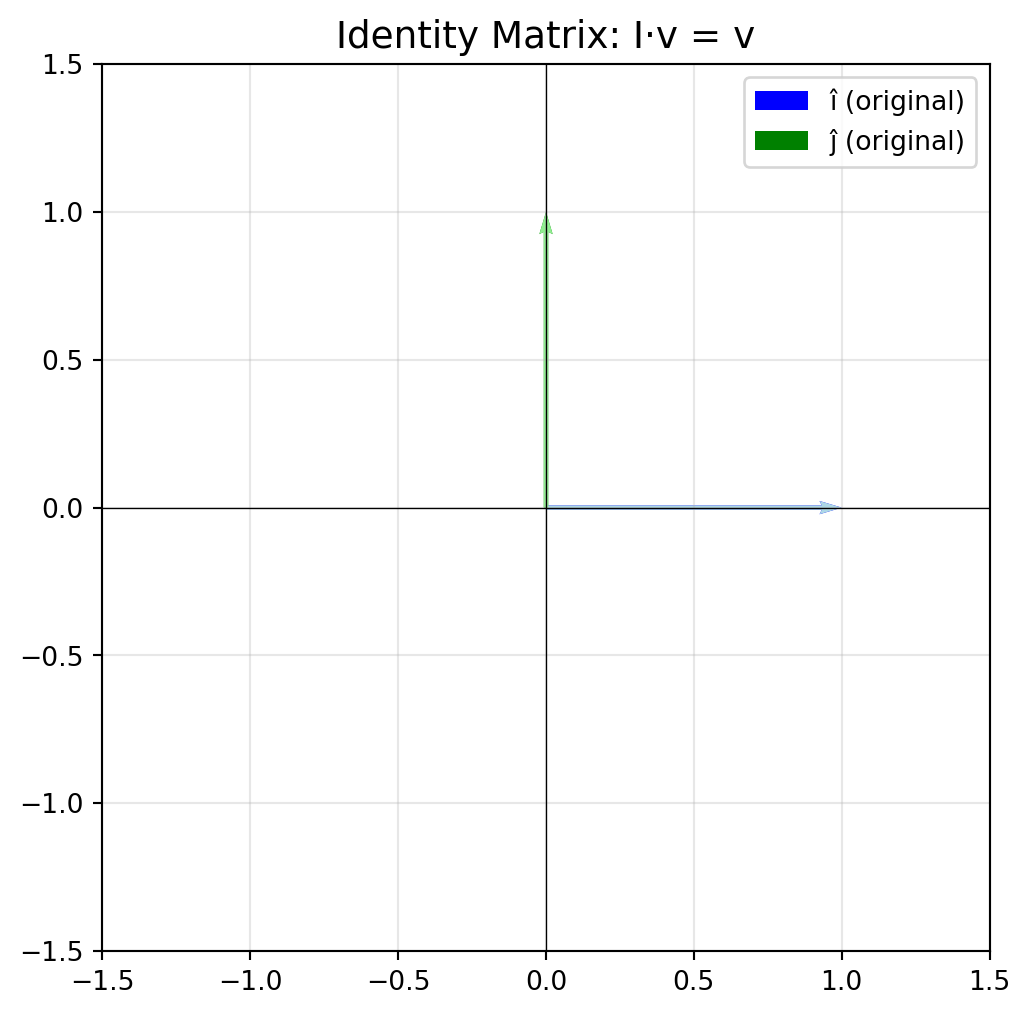

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Create unit vectors
i_hat = np.array([1, 0])
j_hat = np.array([0, 1])

# Identity matrix
I = np.array([[1, 0], [0, 1]])

# Apply transformation
i_transformed = I @ i_hat
j_transformed = I @ j_hat

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(0, 0, i_hat[0], i_hat[1], angles='xy', scale_units='xy', scale=1, color='blue', label='î (original)', width=0.005)
ax.quiver(0, 0, j_hat[0], j_hat[1], angles='xy', scale_units='xy', scale=1, color='green', label='ĵ (original)', width=0.005)
ax.quiver(0, 0, i_transformed[0], i_transformed[1], angles='xy', scale_units='xy', scale=1, color='lightblue', width=0.005)
ax.quiver(0, 0, j_transformed[0], j_transformed[1], angles='xy', scale_units='xy', scale=1, color='lightgreen', width=0.005)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title("Identity Matrix: I·v = v", fontsize=14)
ax.legend()
plt.show()

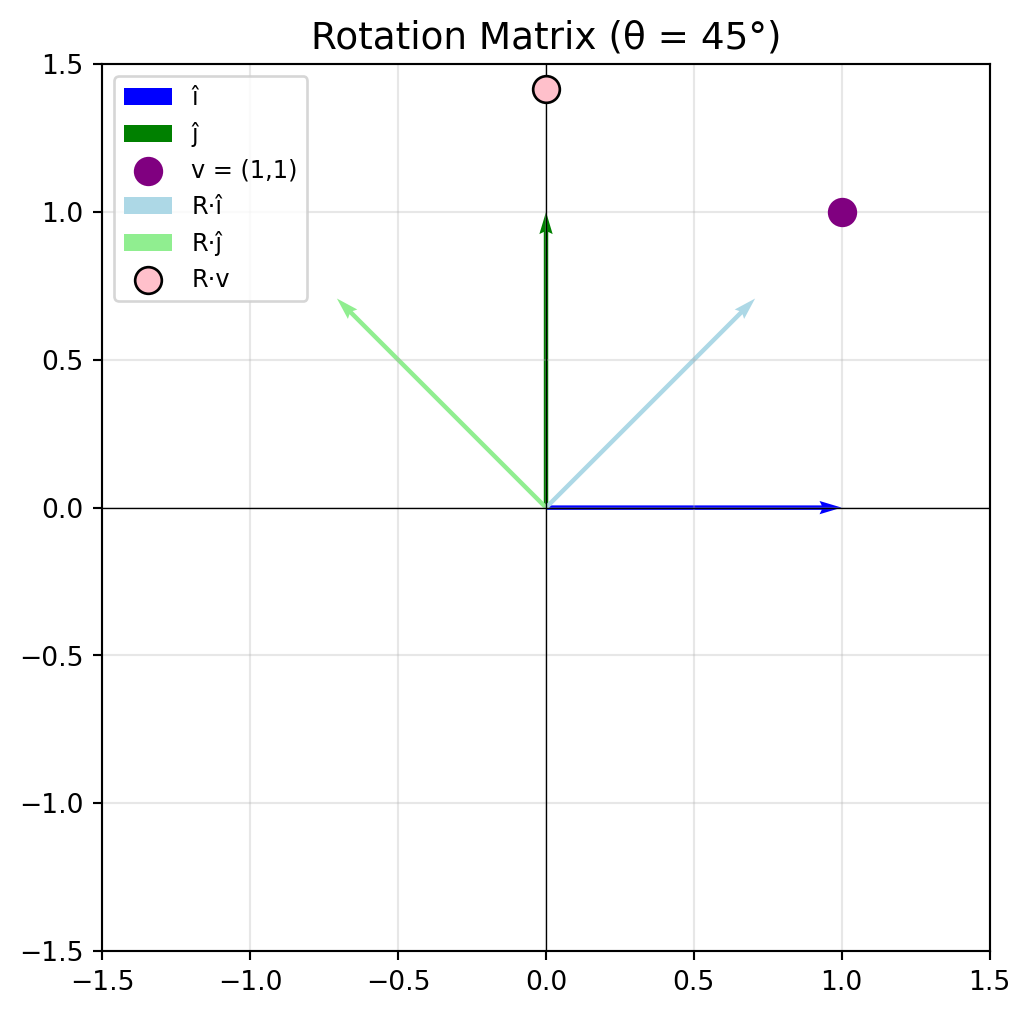

Rotation Matrix R:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

R·v = [0.         1.41421356]


In [4]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.pi / 4  # 45 degrees rotation

# Rotation matrix
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])

# Original vectors
i_hat = np.array([1, 0])
j_hat = np.array([0, 1])
v = np.array([1, 1])

# Transformed vectors
i_rot = R @ i_hat
j_rot = R @ j_hat
v_rot = R @ v

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Original vectors
ax.quiver(0, 0, i_hat[0], i_hat[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.005, label='î')
ax.quiver(0, 0, j_hat[0], j_hat[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.005, label='ĵ')
ax.scatter([v[0]], [v[1]], color='purple', s=100, zorder=5, label='v = (1,1)')

# Rotated vectors
ax.quiver(0, 0, i_rot[0], i_rot[1], angles='xy', scale_units='xy', scale=1, color='lightblue', width=0.005, label="R·î")
ax.quiver(0, 0, j_rot[0], j_rot[1], angles='xy', scale_units='xy', scale=1, color='lightgreen', width=0.005, label="R·ĵ")
ax.scatter([v_rot[0]], [v_rot[1]], color='pink', s=100, zorder=5, edgecolors='black', label="R·v")

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title(f"Rotation Matrix (θ = {np.degrees(theta):.0f}°)", fontsize=14)
ax.legend(loc='upper left', fontsize=9)
plt.show()

print(f"Rotation Matrix R:\n{R}")
print(f"\nR·v = {v_rot}")

In [5]:
import numpy as np

# Scaling matrix (stretch x by 2, compress y by 0.5)
S = np.array([[2, 0], [0, 0.5]])

# Test vector
v = np.array([1, 1])

# Apply scaling
v_scaled = S @ v

print(f"Scaling Matrix S:\n{S}")
print(f"\nOriginal vector v = {v}")
print(f"Scaled vector S·v = {v_scaled}")
print(f"\nInterpretation: x-component doubled, y-component halved")

Scaling Matrix S:
[[2.  0. ]
 [0.  0.5]]

Original vector v = [1 1]
Scaled vector S·v = [2.  0.5]

Interpretation: x-component doubled, y-component halved


C:\Users\SIJUKSWAMY\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\transforms.py:1865: ComplexWarning:

Casting complex values to real discards the imaginary part



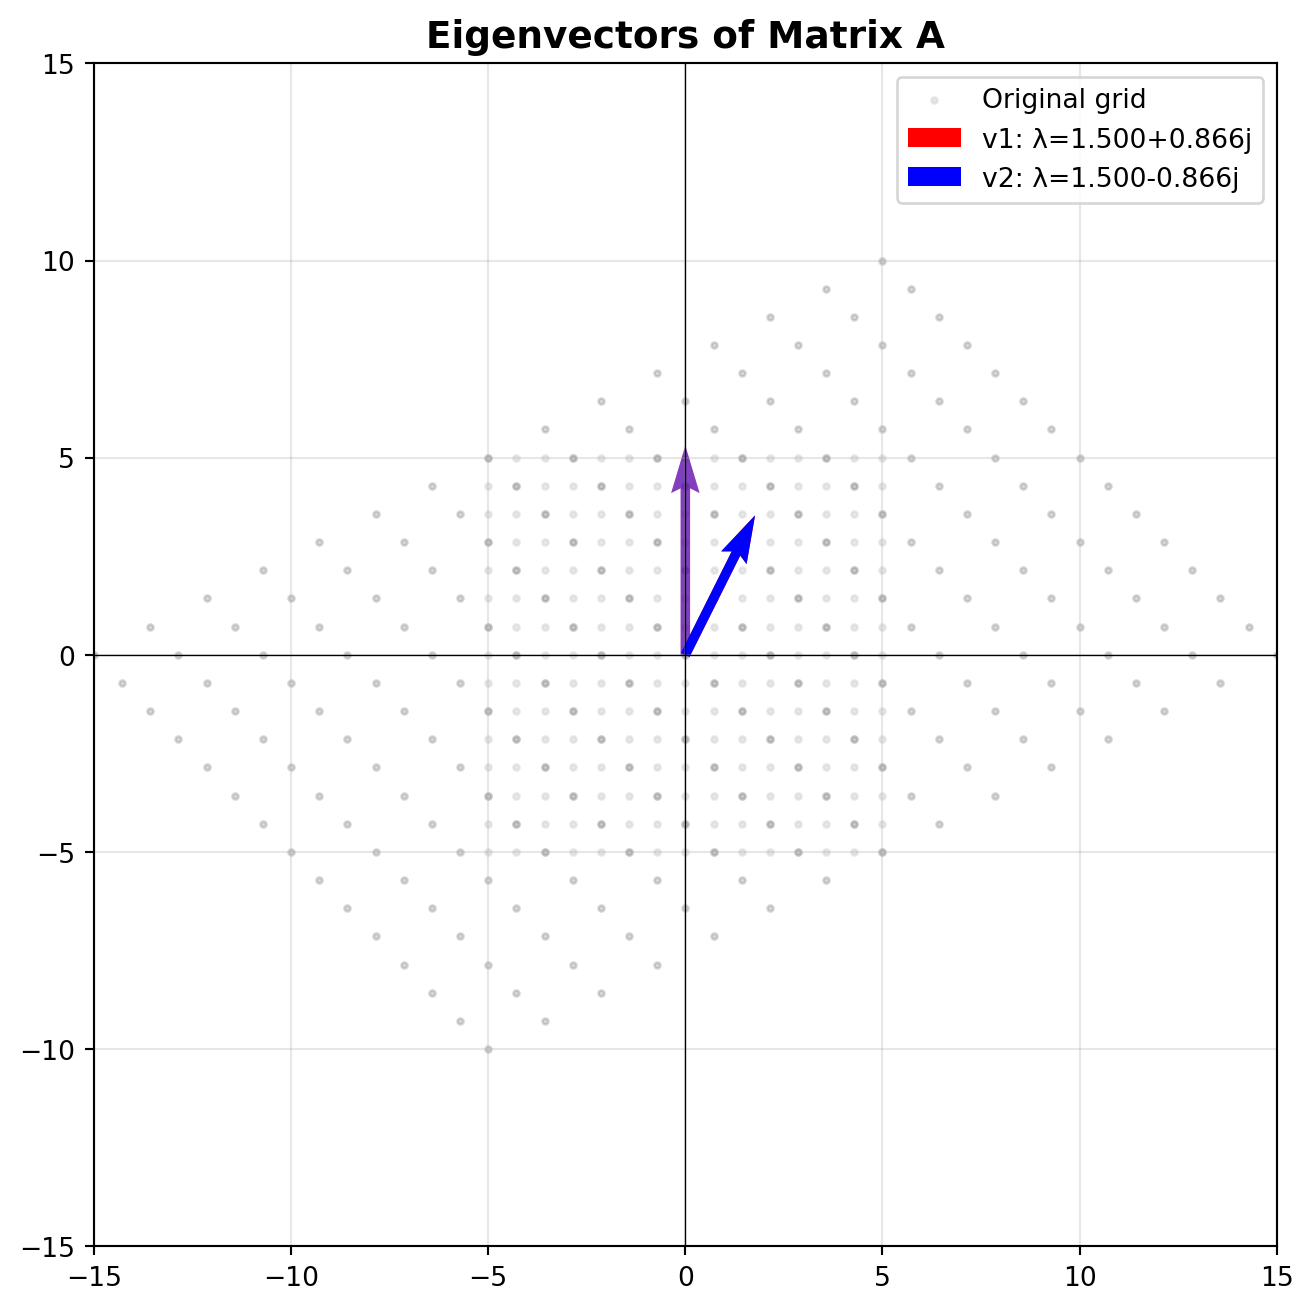

Eigenvalues: [1.5+0.8660254j 1.5-0.8660254j]

Eigenvectors (columns):
[[0.35355339+0.61237244j 0.35355339-0.61237244j]
 [0.70710678+0.j         0.70710678-0.j        ]]

Verification (Av = λv):

Eigenvector 1:
  A·v = [2.22044605e-16+1.22474487j 1.06066017e+00+0.61237244j]
  λ·v = [3.60822483e-16+1.22474487j 1.06066017e+00+0.61237244j]
  Match: True

Eigenvector 2:
  A·v = [2.22044605e-16-1.22474487j 1.06066017e+00-0.61237244j]
  λ·v = [3.60822483e-16-1.22474487j 1.06066017e+00-0.61237244j]
  Match: True


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define a matrix A
A = np.array([[2, -1], 
              [1,  1]])

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

# Create a grid of points
x = np.linspace(-5, 5, 15)
y = np.linspace(-5, 5, 15)
X, Y = np.meshgrid(x, y)
points = np.vstack([X.flatten(), Y.flatten()])

# Transform the points
transformed_points = A @ points

# Plotting
fig, ax = plt.subplots(figsize=(8, 8))

# Plot original grid (light)
ax.scatter(points[0], points[1], c='lightgray', s=5, alpha=0.5, label='Original grid')

# Plot transformed grid
ax.scatter(transformed_points[0], transformed_points[1], c='gray', s=5, alpha=0.3)

# Plot eigenvectors (scaled for visibility)
colors = ['red', 'blue']
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    # Scale eigenvector for visualization
    scale = 5
    ax.quiver(0, 0, v[0]*scale, v[1]*scale, 
              angles='xy', scale_units='xy', scale=1, 
              color=colors[i], width=0.008, 
              label=f'v{i+1}: λ={eigenvalues[i]:.3f}')
    # Plot the transformed eigenvector
    Av = A @ v
    ax.quiver(0, 0, Av[0]*scale, Av[1]*scale, 
              angles='xy', scale_units='xy', scale=1, 
              color=colors[i], width=0.008, alpha=0.5, linestyle='--')

ax.set_xlim(-15, 15)
ax.set_ylim(-15, 15)
ax.set_aspect('equal')
ax.set_title('Eigenvectors of Matrix A', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.legend(fontsize=10)
plt.show()

print("Eigenvalues:", eigenvalues)
print("\nEigenvectors (columns):")
print(eigenvectors)

# Verify: Av = λv
print("\nVerification (Av = λv):")
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    Av = A @ v
    lam_v = lam * v
    print(f"\nEigenvector {i+1}:")
    print(f"  A·v = {Av}")
    print(f"  λ·v = {lam_v}")
    print(f"  Match: {np.allclose(Av, lam_v)}")

In [7]:
import numpy as np

# Define a symmetric matrix (common in ML - e.g., covariance matrices)
A = np.array([[4, 2],
              [2, 3]])

print("Matrix A:")
print(A)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

print(f"\nEigenvalues: {eigenvalues}")
print(f"\nEigenvectors (each column is an eigenvector):")
print(eigenvectors)

# Verify the eigendecomposition
print("\nVerification:")
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    residual = np.linalg.norm(A @ v - lam * v)
    print(f"  ||A·v{i+1} - λ{i+1}·v{i+1}|| = {residual:.2e}")

# Reconstruct the matrix using eigendecomposition
# A = V Λ V^(-1)
Lambda = np.diag(eigenvalues)
V = eigenvectors
A_reconstructed = V @ Lambda @ np.linalg.inv(V)

print(f"\nReconstructed A:")
print(A_reconstructed)
print(f"\nReconstruction error: {np.linalg.norm(A - A_reconstructed):.2e}")

Matrix A:
[[4 2]
 [2 3]]

Eigenvalues: [5.56155281 1.43844719]

Eigenvectors (each column is an eigenvector):
[[ 0.78820544 -0.61541221]
 [ 0.61541221  0.78820544]]

Verification:
  ||A·v1 - λ1·v1|| = 4.44e-16
  ||A·v2 - λ2·v2|| = 1.11e-16

Reconstructed A:
[[4. 2.]
 [2. 3.]]

Reconstruction error: 6.66e-16


Covariance Matrix:
[[1.00502513 0.81957449]
 [0.81957449 1.00502513]]

Eigenvalues (variance explained): [1.82459962 0.18545063]
Proportion of variance: [0.90773831 0.09226169]

PCA Components (should match eigenvectors):
[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]

Explained variance: [1.82459962 0.18545063]


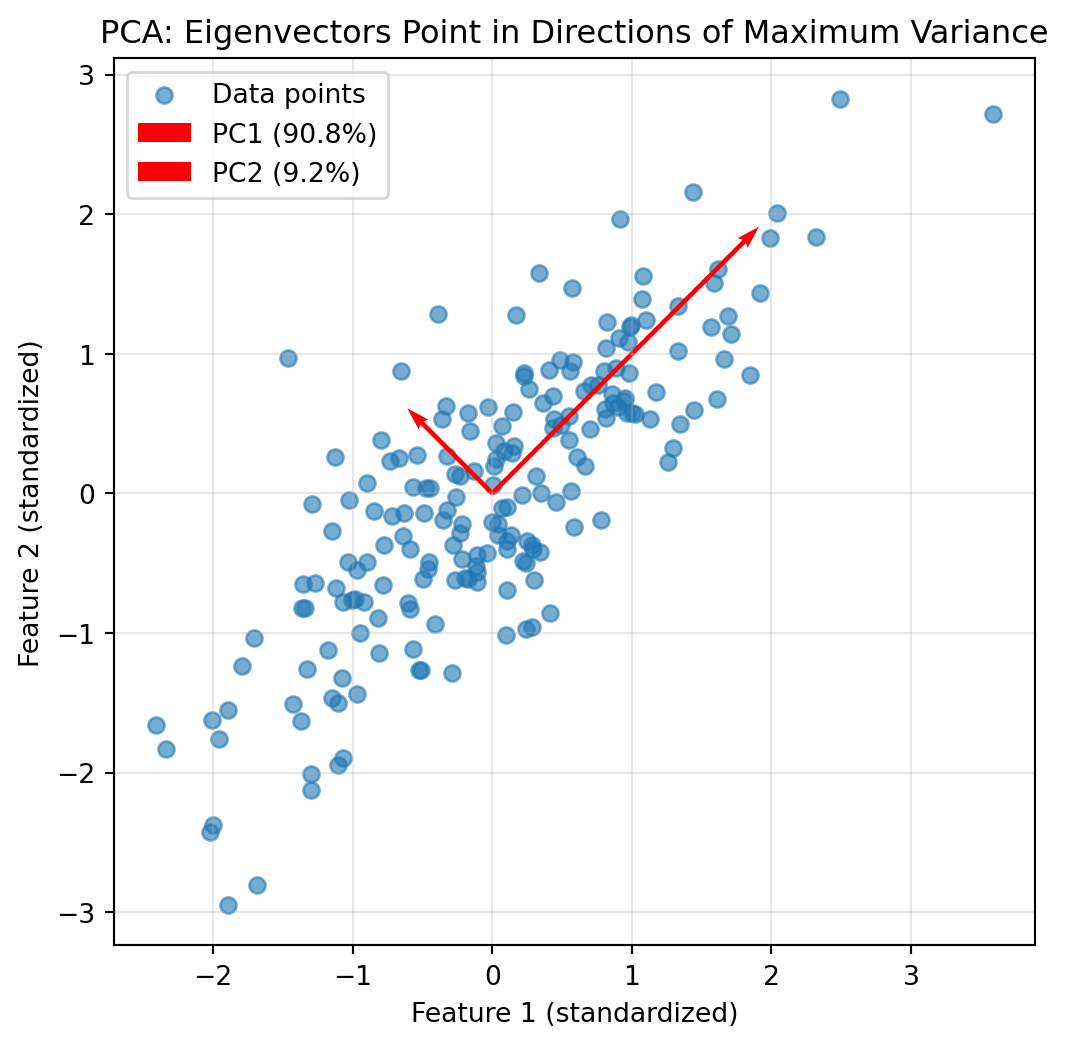

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Generate correlated 2D data
np.random.seed(42)
mean = [0, 0]
cov = [[3, 2], [2, 2]]  # Covariance matrix
data = np.random.multivariate_normal(mean, cov, 200)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Compute covariance matrix
cov_matrix = np.cov(data_scaled.T)
print("Covariance Matrix:")
print(cov_matrix)

# Compute eigenvalues and eigenvectors of covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print(f"\nEigenvalues (variance explained): {eigenvalues}")
print(f"Proportion of variance: {eigenvalues / eigenvalues.sum()}")

# Apply PCA
pca = PCA(n_components=2)
pca.fit(data_scaled)

print(f"\nPCA Components (should match eigenvectors):")
print(pca.components_)
print(f"\nExplained variance: {pca.explained_variance_}")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(data_scaled[:, 0], data_scaled[:, 1], alpha=0.6, label='Data points')

# Plot eigenvectors (scaled)
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i] * np.sqrt(eigenvalues[i]) * 2
    ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
              color='red', width=0.005, label=f'PC{i+1} ({eigenvalues[i]/eigenvalues.sum()*100:.1f}%)')

ax.set_xlabel('Feature 1 (standardized)')
ax.set_ylabel('Feature 2 (standardized)')
ax.set_title('PCA: Eigenvectors Point in Directions of Maximum Variance')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.show()

Starting Theta: 10.0000, Initial Cost: 105.0000
--------------------------------------------------
Step  1: Theta = 8.0000, Cost = 69.0000, Gradient = 20.0000
Step  4: Theta = 4.0960, Cost = 21.7772, Gradient = 10.2400
Step  7: Theta = 2.0972, Cost = 9.3980, Gradient = 5.2429
Step 10: Theta = 1.0737, Cost = 6.1529, Gradient = 2.6844
Step 13: Theta = 0.5498, Cost = 5.3022, Gradient = 1.3744
--------------------------------------------------
Final Optimized Theta: 0.3518
Final Cost: 5.1238


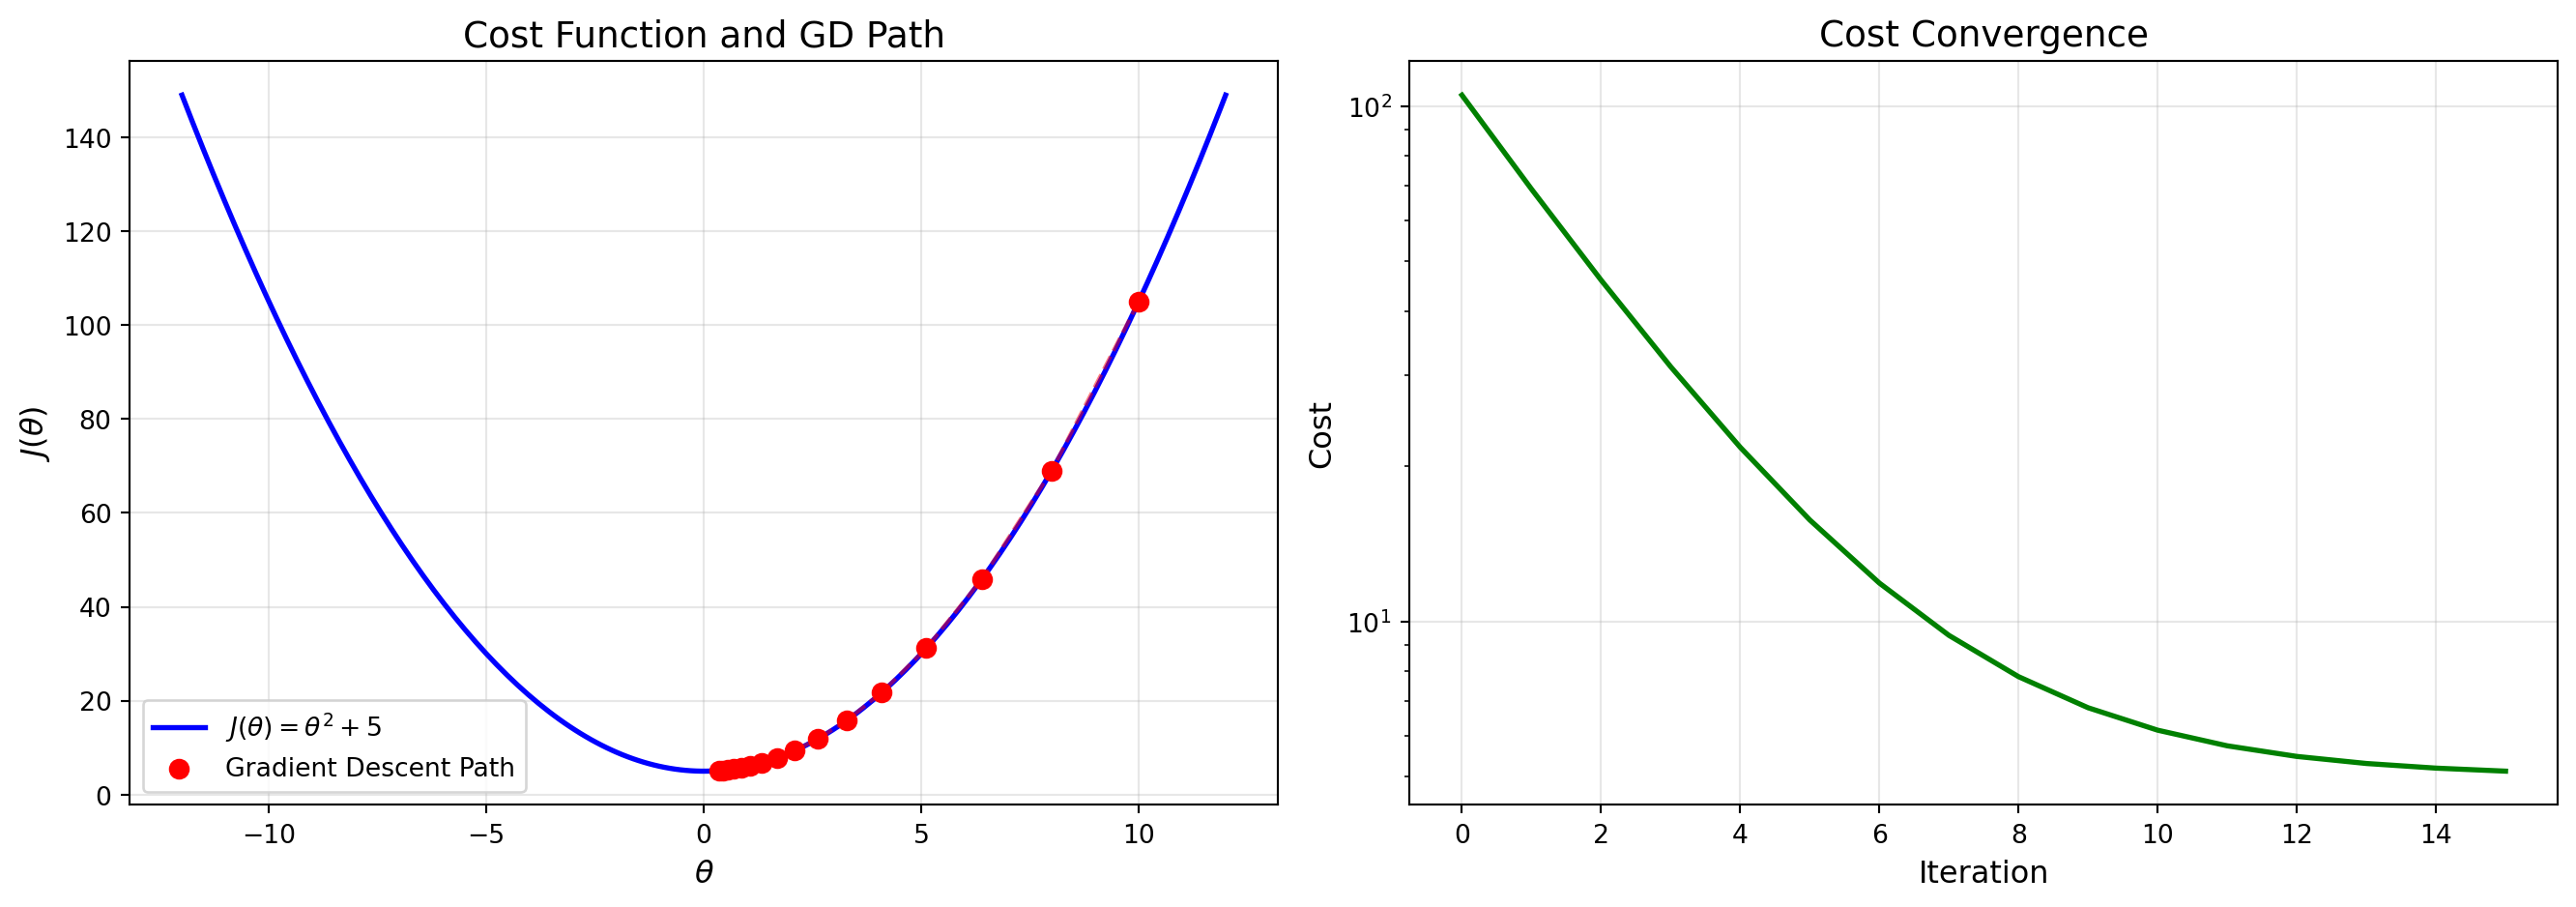

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Our objective function: J(theta) = theta^2 + 5
def J(theta):
    return theta**2 + 5

# 2. The derivative: dJ/dtheta = 2*theta
def gradient(theta):
    return 2 * theta

# 3. The Optimization Loop
theta = 10.0      # Start at a random high point on the mountain
alpha = 0.1       # Step size (Learning rate)
epochs = 15       # How many steps we take

# Store history for plotting
theta_history = [theta]
cost_history = [J(theta)]

print(f"Starting Theta: {theta:.4f}, Initial Cost: {J(theta):.4f}")
print("-" * 50)

for i in range(epochs):
    grad = gradient(theta)
    theta = theta - (alpha * grad)  # The update rule
    
    theta_history.append(theta)
    cost_history.append(J(theta))
    
    if i % 3 == 0:
        print(f"Step {i+1:>2}: Theta = {theta:.4f}, Cost = {J(theta):.4f}, Gradient = {grad:.4f}")

print("-" * 50)
print(f"Final Optimized Theta: {theta:.4f}")
print(f"Final Cost: {J(theta):.4f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cost function with path
theta_vals = np.linspace(-12, 12, 200)
ax1.plot(theta_vals, J(theta_vals), 'b-', linewidth=2, label=r'$J(\theta) = \theta^2 + 5$')
ax1.scatter(theta_history, cost_history, c='red', s=50, zorder=5, label='Gradient Descent Path')
ax1.plot(theta_history, cost_history, 'r--', alpha=0.5)
ax1.set_xlabel(r'$\theta$', fontsize=12)
ax1.set_ylabel(r'$J(\theta)$', fontsize=12)
ax1.set_title('Cost Function and GD Path', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Cost over iterations
ax2.plot(range(len(cost_history)), cost_history, 'g-', linewidth=2)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Cost', fontsize=12)
ax2.set_title('Cost Convergence', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

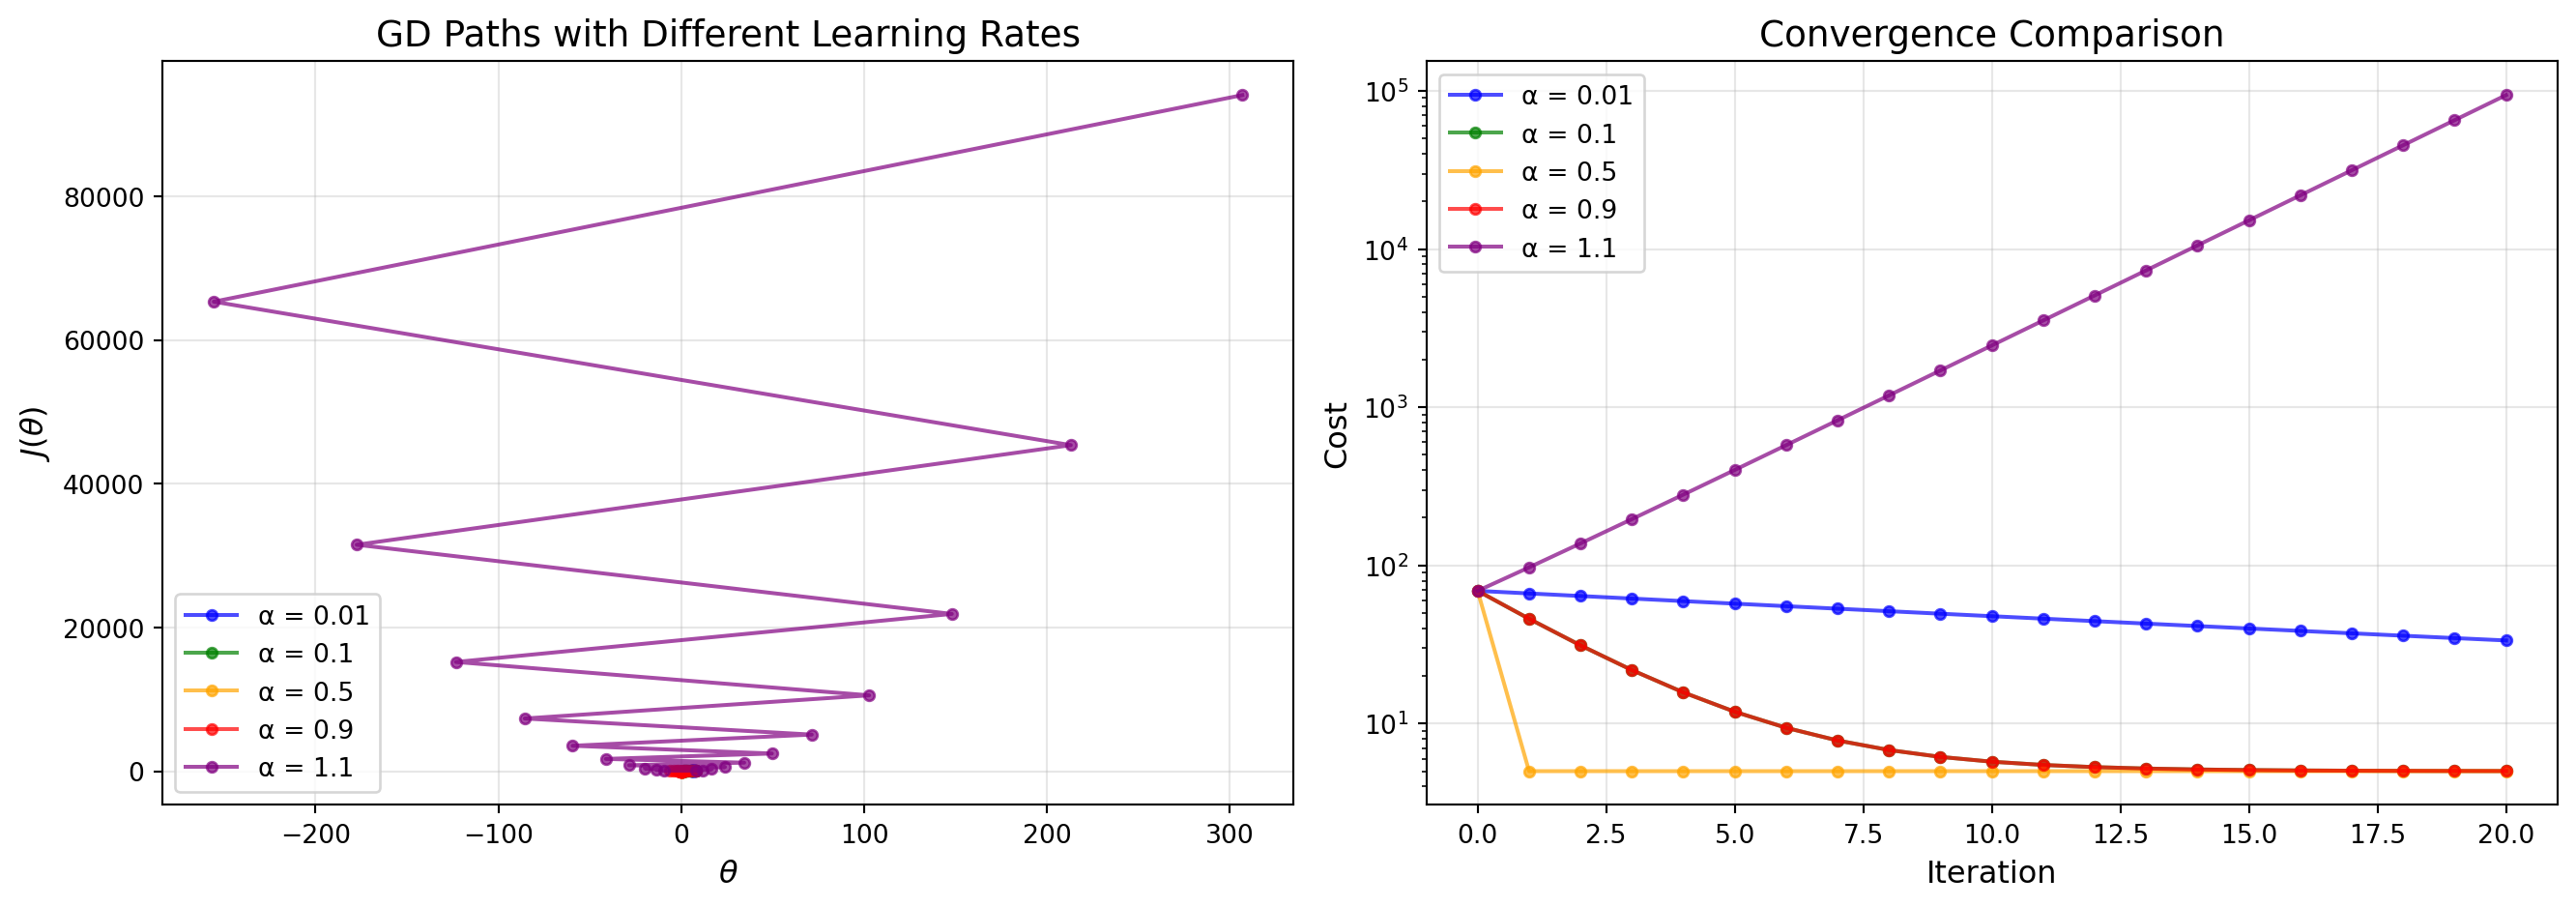

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def J(theta):
    return theta**2 + 5

def gradient(theta):
    return 2 * theta

# Different learning rates
learning_rates = [0.01, 0.1, 0.5, 0.9, 1.1]
colors = ['blue', 'green', 'orange', 'red', 'purple']
theta_init = 8.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr, color in zip(learning_rates, colors):
    theta = theta_init
    theta_history = [theta]
    cost_history = [J(theta)]
    
    for _ in range(20):
        grad = gradient(theta)
        theta = theta - lr * grad
        theta_history.append(theta)
        cost_history.append(J(theta))
    
    # Plot path on cost function
    axes[0].plot(theta_history, cost_history, 'o-', color=color, alpha=0.7, 
                 label=f'α = {lr}', markersize=4)
    
    # Plot cost convergence
    axes[1].plot(range(len(cost_history)), cost_history, 'o-', color=color, alpha=0.7, 
                 label=f'α = {lr}', markersize=4)

axes[0].set_xlabel(r'$\theta$', fontsize=12)
axes[0].set_ylabel(r'$J(\theta)$', fontsize=12)
axes[0].set_title('GD Paths with Different Learning Rates', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('Cost', fontsize=12)
axes[1].set_title('Convergence Comparison', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

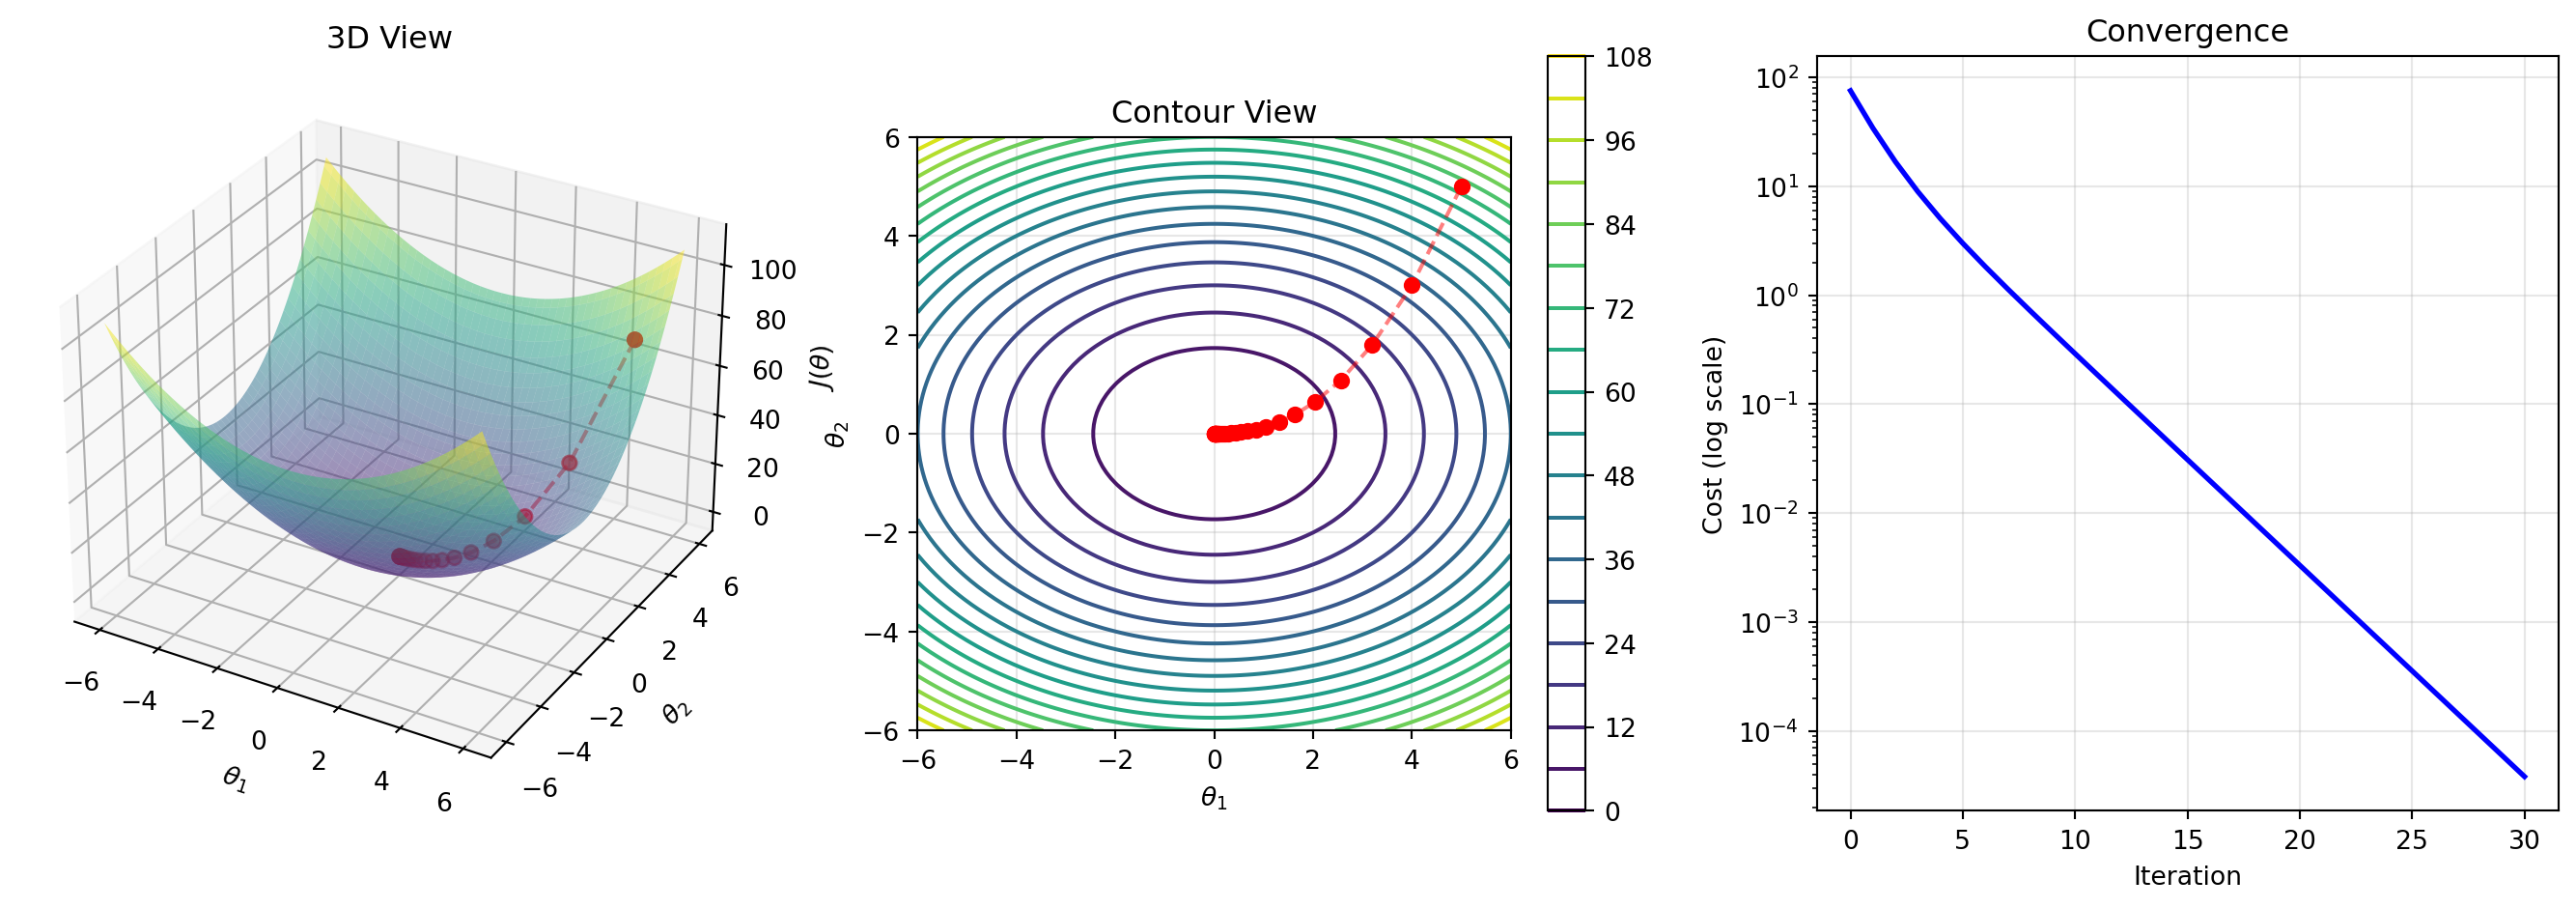

Initial point: (5.00, 5.00)
Final point: (0.006190, 0.000001)
Minimum is at (0, 0)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Cost function: J(theta1, theta2) = theta1^2 + 2*theta2^2
def J_2d(theta):
    return theta[0]**2 + 2*theta[1]**2

# Gradient
def gradient_2d(theta):
    return np.array([2*theta[0], 4*theta[1]])

# Gradient Descent
theta = np.array([5.0, 5.0])
alpha = 0.1
iterations = 30

theta_history = [theta.copy()]
cost_history = [J_2d(theta)]

for _ in range(iterations):
    grad = gradient_2d(theta)
    theta = theta - alpha * grad
    theta_history.append(theta.copy())
    cost_history.append(J_2d(theta))

theta_history = np.array(theta_history)
cost_history = np.array(cost_history)

# Create mesh for surface plot
t1 = np.linspace(-6, 6, 100)
t2 = np.linspace(-6, 6, 100)
T1, T2 = np.meshgrid(t1, t2)
J_surface = T1**2 + 2*T2**2

# 3D Plot
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(T1, T2, J_surface, alpha=0.5, cmap='viridis')
ax1.scatter(theta_history[:, 0], theta_history[:, 1], cost_history, 
            c='red', s=30, label='GD Path')
ax1.plot(theta_history[:, 0], theta_history[:, 1], cost_history, 'r--', alpha=0.5)
ax1.set_xlabel(r'$\theta_1$')
ax1.set_ylabel(r'$\theta_2$')
ax1.set_zlabel(r'$J(\theta)$')
ax1.set_title('3D View')

ax2 = fig.add_subplot(132)
contour = ax2.contour(T1, T2, J_surface, levels=20, cmap='viridis')
ax2.scatter(theta_history[:, 0], theta_history[:, 1], c='red', s=30, zorder=5)
ax2.plot(theta_history[:, 0], theta_history[:, 1], 'r--', alpha=0.5)
ax2.set_xlabel(r'$\theta_1$')
ax2.set_ylabel(r'$\theta_2$')
ax2.set_title('Contour View')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')
plt.colorbar(contour, ax=ax2)

ax3 = fig.add_subplot(133)
ax3.semilogy(range(len(cost_history)), cost_history, 'b-', linewidth=2)
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Cost (log scale)')
ax3.set_title('Convergence')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Initial point: ({theta_history[0, 0]:.2f}, {theta_history[0, 1]:.2f})")
print(f"Final point: ({theta_history[-1, 0]:.6f}, {theta_history[-1, 1]:.6f})")
print(f"Minimum is at (0, 0)")

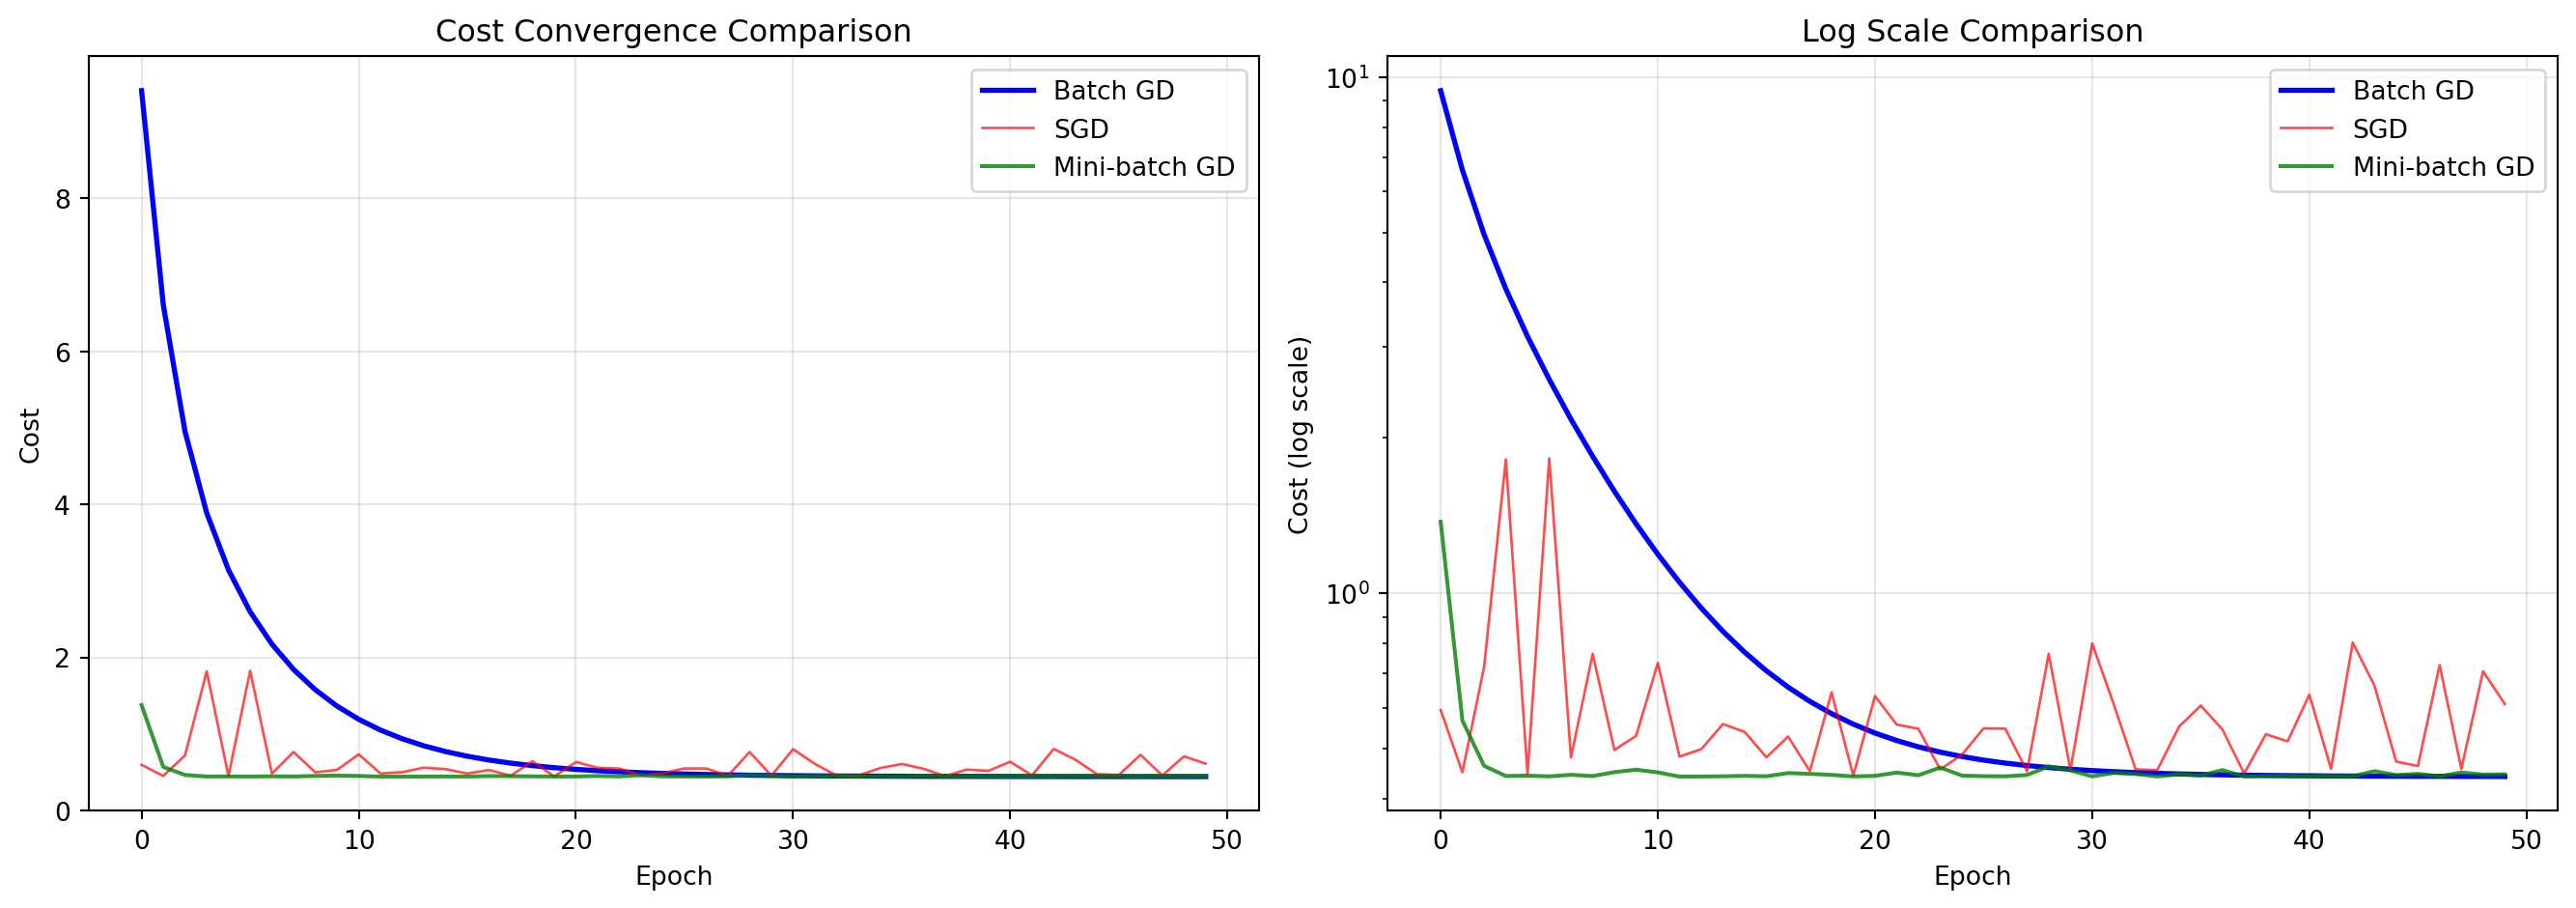

Batch GD final theta: [3.98554849 2.92641924]
SGD final theta: [4.1664442  2.63083645]
Mini-batch final theta: [3.9599274  2.97073399]

True parameters: [4, 3]


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Generate some data for linear regression
np.random.seed(42)
X = 2 * np.random.randn(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Add bias term
X_b = np.c_[np.ones((100, 1)), X]

# Cost function for linear regression
def compute_cost(X, y, theta):
    m = len(y)
    return (1/(2*m)) * np.sum((X @ theta - y)**2)

def compute_gradient(X, y, theta):
    m = len(y)
    return (1/m) * X.T @ (X @ theta - y)

# Batch Gradient Descent
def batch_gd(X, y, theta, alpha, epochs):
    cost_history = []
    for _ in range(epochs):
        grad = compute_gradient(X, y, theta)
        theta = theta - alpha * grad
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history

# Stochastic Gradient Descent
def sgd(X, y, theta, alpha, epochs):
    cost_history = []
    m = len(y)
    for epoch in range(epochs):
        # Shuffle data
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        for i in range(m):
            xi = X_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]
            grad = (xi.T @ (xi @ theta - yi))  # Gradient for single sample
            theta = theta - alpha * grad
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history

# Mini-batch Gradient Descent
def mini_batch_gd(X, y, theta, alpha, epochs, batch_size=10):
    cost_history = []
    m = len(y)
    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        for i in range(0, m, batch_size):
            xi = X_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]
            grad = (1/batch_size) * xi.T @ (xi @ theta - yi)
            theta = theta - alpha * grad
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history

# Run all three
theta_init = np.random.randn(2, 1)
alpha = 0.1
epochs = 50

theta_batch, cost_batch = batch_gd(X_b, y, theta_init.copy(), alpha, epochs)
theta_sgd, cost_sgd = sgd(X_b, y, theta_init.copy(), alpha, epochs)
theta_mini, cost_mini = mini_batch_gd(X_b, y, theta_init.copy(), alpha, epochs, batch_size=10)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(len(cost_batch)), cost_batch, 'b-', linewidth=2, label='Batch GD')
axes[0].plot(range(len(cost_sgd)), cost_sgd, 'r-', linewidth=1, alpha=0.7, label='SGD')
axes[0].plot(range(len(cost_mini)), cost_mini, 'g-', linewidth=1.5, alpha=0.8, label='Mini-batch GD')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cost')
axes[0].set_title('Cost Convergence Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(range(len(cost_batch)), cost_batch, 'b-', linewidth=2, label='Batch GD')
axes[1].semilogy(range(len(cost_sgd)), cost_sgd, 'r-', linewidth=1, alpha=0.7, label='SGD')
axes[1].semilogy(range(len(cost_mini)), cost_mini, 'g-', linewidth=1.5, alpha=0.8, label='Mini-batch GD')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cost (log scale)')
axes[1].set_title('Log Scale Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Batch GD final theta: {theta_batch.flatten()}")
print(f"SGD final theta: {theta_sgd.flatten()}")
print(f"Mini-batch final theta: {theta_mini.flatten()}")
print(f"\nTrue parameters: [4, 3]")

In [13]:
import numpy as np

# Medical testing example
# Disease prevalence: 1% of population
P_disease = 0.01

# Test sensitivity: P(Positive | Disease) = 99%
P_positive_given_disease = 0.99

# Test specificity: P(Negative | No Disease) = 95%
P_negative_given_no_disease = 0.95
P_positive_given_no_disease = 1 - P_negative_given_no_disease

# Question: If you test positive, what's the probability you actually have the disease?
# P(Disease | Positive) = ?

# Using Bayes' theorem:
# P(Disease | Positive) = P(Positive | Disease) * P(Disease) / P(Positive)

# P(Positive) = P(Positive | Disease) * P(Disease) + P(Positive | No Disease) * P(No Disease)
P_positive = (P_positive_given_disease * P_disease + 
              P_positive_given_no_disease * (1 - P_disease))

P_disease_given_positive = (P_positive_given_disease * P_disease) / P_positive

print("Medical Testing Example")
print("=" * 50)
print(f"Disease prevalence: {P_disease*100:.1f}%")
print(f"Test sensitivity: {P_positive_given_disease*100:.1f}%")
print(f"Test specificity: {P_negative_given_no_disease*100:.1f}%")
print()
print(f"P(Positive test) = {P_positive:.4f}")
print(f"P(Disease | Positive test) = {P_disease_given_positive:.4f}")
print(f"P(Disease | Positive test) = {P_disease_given_positive*100:.2f}%")
print()
print("Surprising result! Even with a 99% accurate test,")
print(f"a positive result only means {P_disease_given_positive*100:.1f}% chance of disease.")
print("This is because the disease is rare (base rate fallacy).")

Medical Testing Example
Disease prevalence: 1.0%
Test sensitivity: 99.0%
Test specificity: 95.0%

P(Positive test) = 0.0594
P(Disease | Positive test) = 0.1667
P(Disease | Positive test) = 16.67%

Surprising result! Even with a 99% accurate test,
a positive result only means 16.7% chance of disease.
This is because the disease is rare (base rate fallacy).


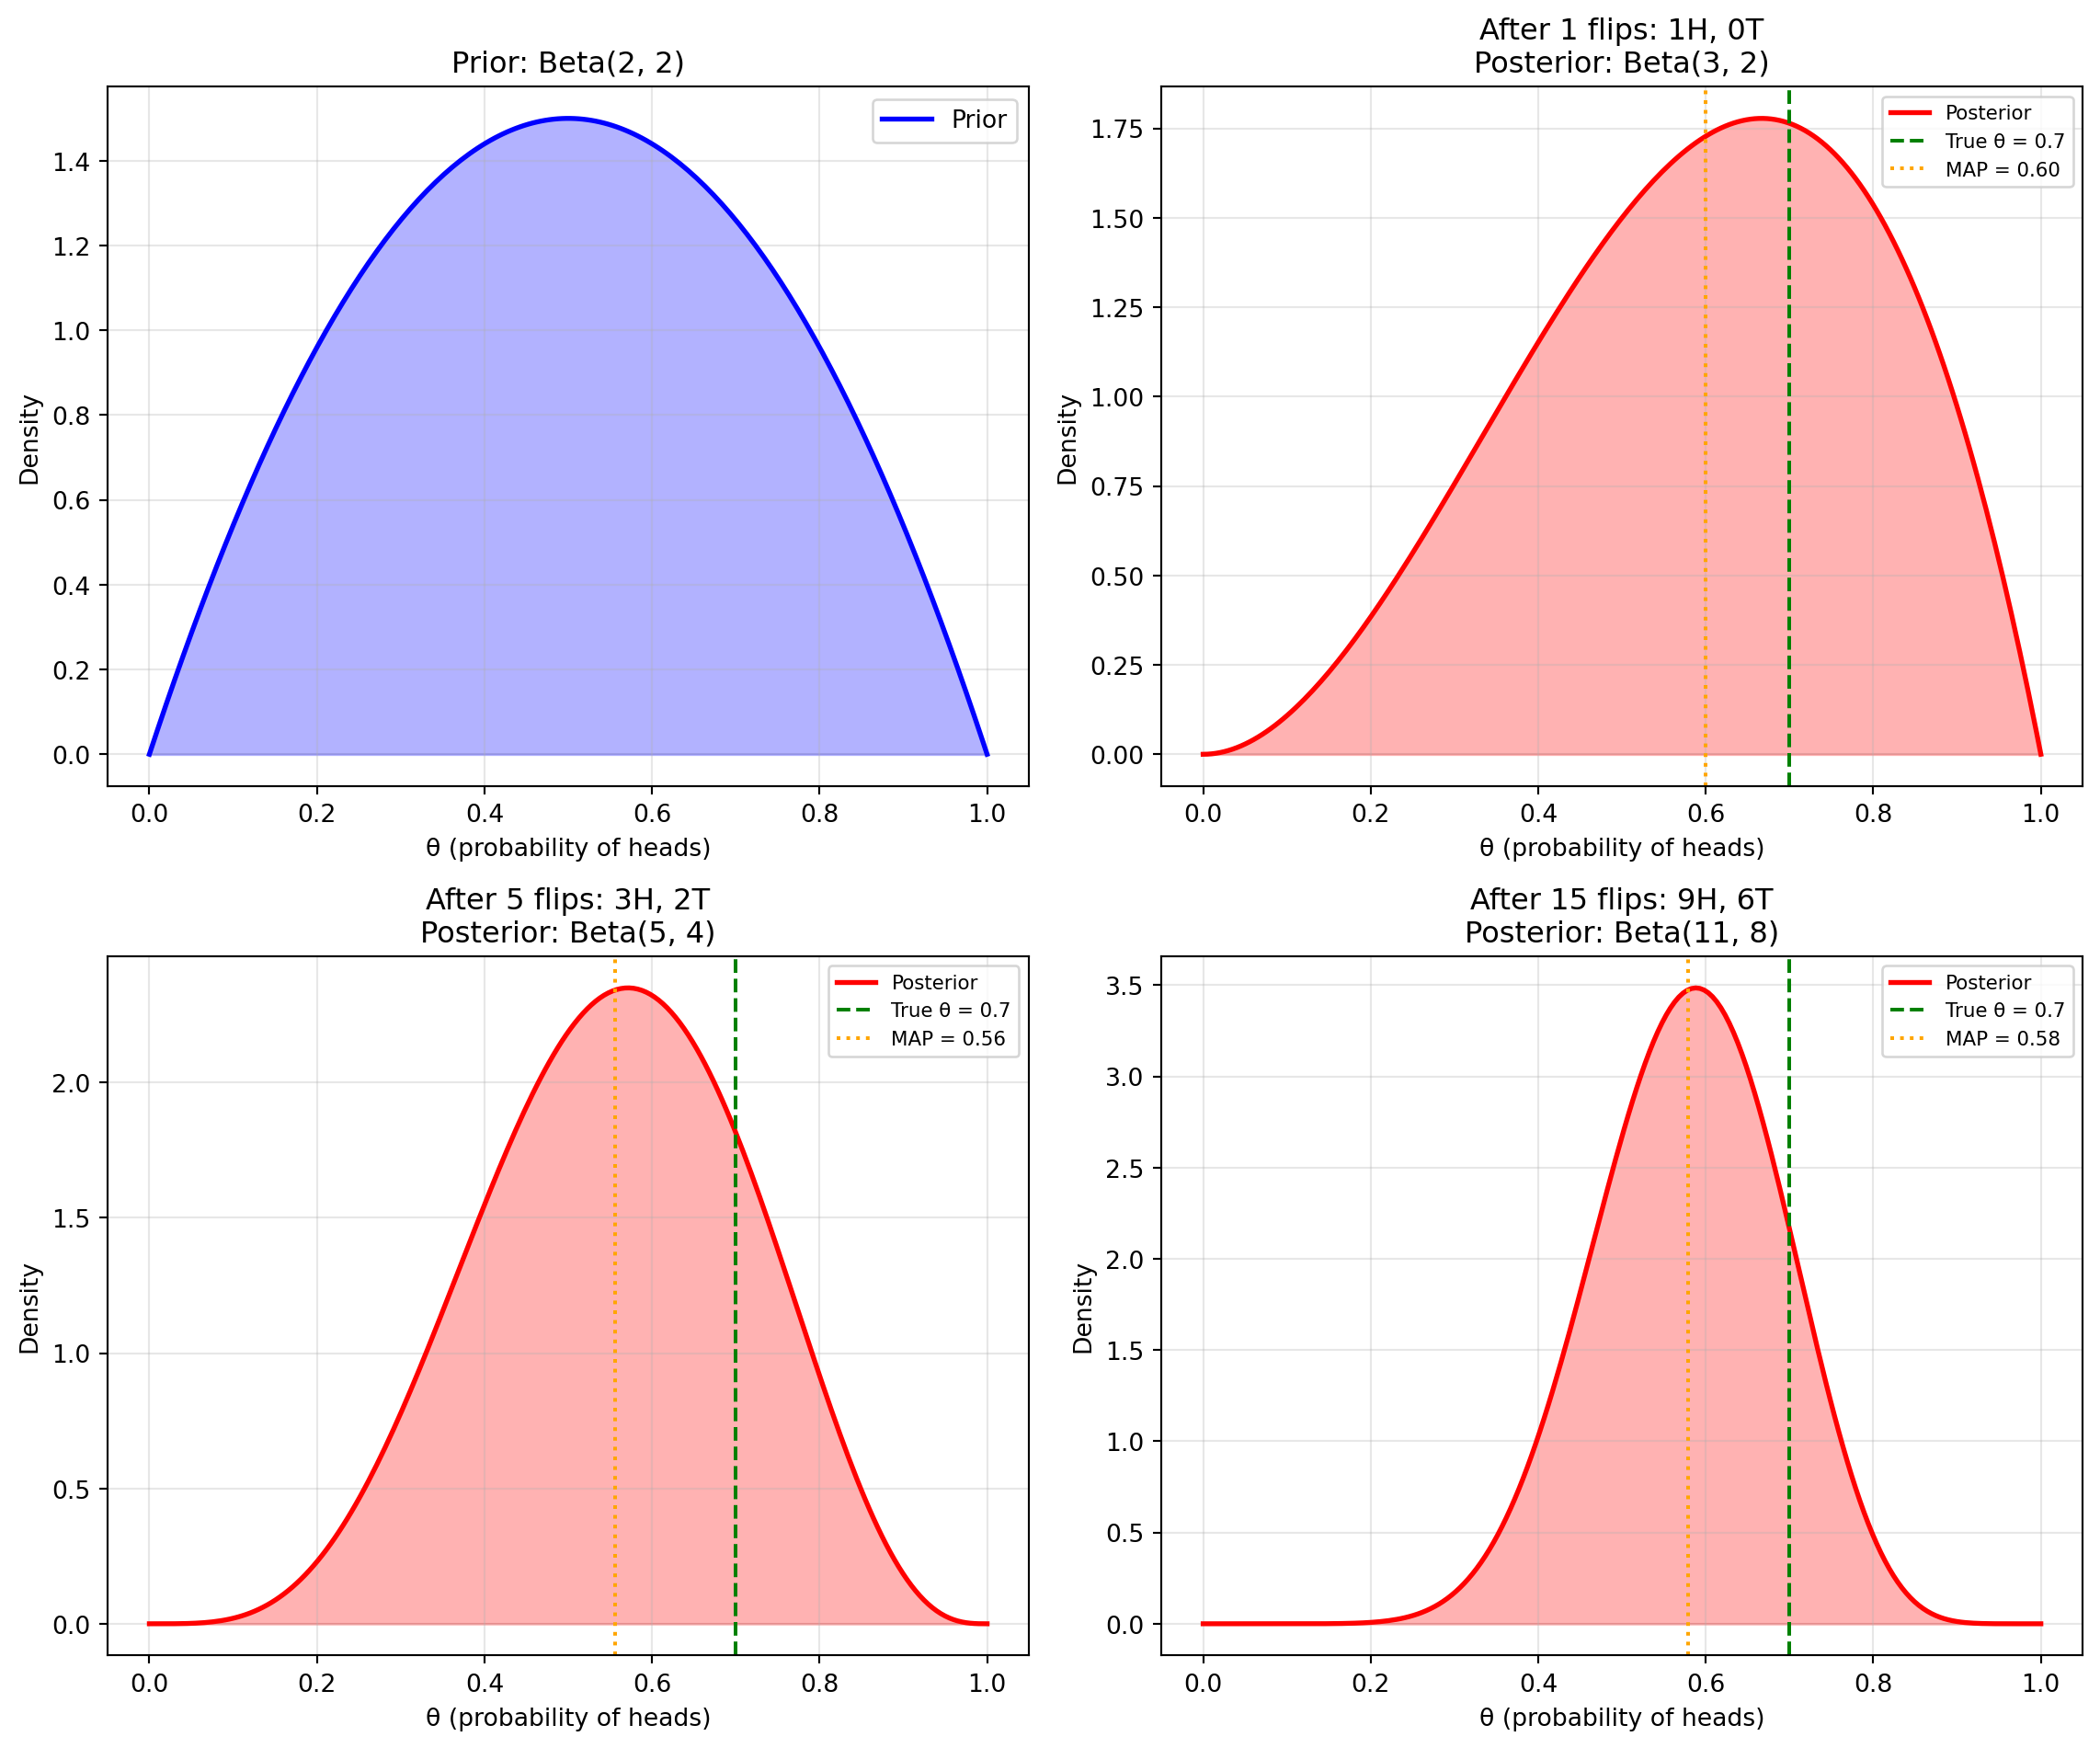

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Prior: We believe the coin is fair (Beta distribution)
alpha_prior = 2  # "pseudo-heads"
beta_prior = 2   # "pseudo-tails"

# Simulate coin flips
np.random.seed(42)
true_bias = 0.7  # The coin is actually biased towards heads
flips = np.random.random(20) < true_bias

# Update posterior after each flip
posteriors = []
x = np.linspace(0, 1, 200)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot prior
ax = axes[0]
prior = beta.pdf(x, alpha_prior, beta_prior)
ax.plot(x, prior, 'b-', linewidth=2, label='Prior')
ax.fill_between(x, prior, alpha=0.3, color='blue')
ax.set_title(f'Prior: Beta({alpha_prior}, {beta_prior})')
ax.set_xlabel('θ (probability of heads)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

# Update and plot after selected numbers of flips
update_points = [1, 5, 15]
for i, n_updates in enumerate(update_points):
    ax = axes[i + 1]
    
    # Update parameters
    alpha_post = alpha_prior + sum(flips[:n_updates])
    beta_post = beta_prior + n_updates - sum(flips[:n_updates])
    
    posterior = beta.pdf(x, alpha_post, beta_post)
    ax.plot(x, posterior, 'r-', linewidth=2, label=f'Posterior')
    ax.fill_between(x, posterior, alpha=0.3, color='red')
    ax.axvline(true_bias, color='green', linestyle='--', label=f'True θ = {true_bias}')
    ax.axvline(alpha_post/(alpha_post+beta_post), color='orange', linestyle=':', 
               label=f'MAP = {alpha_post/(alpha_post+beta_post):.2f}')
    
    heads = sum(flips[:n_updates])
    ax.set_title(f'After {n_updates} flips: {heads}H, {n_updates-heads}T\nPosterior: Beta({alpha_post}, {beta_post})')
    ax.set_xlabel('θ (probability of heads)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

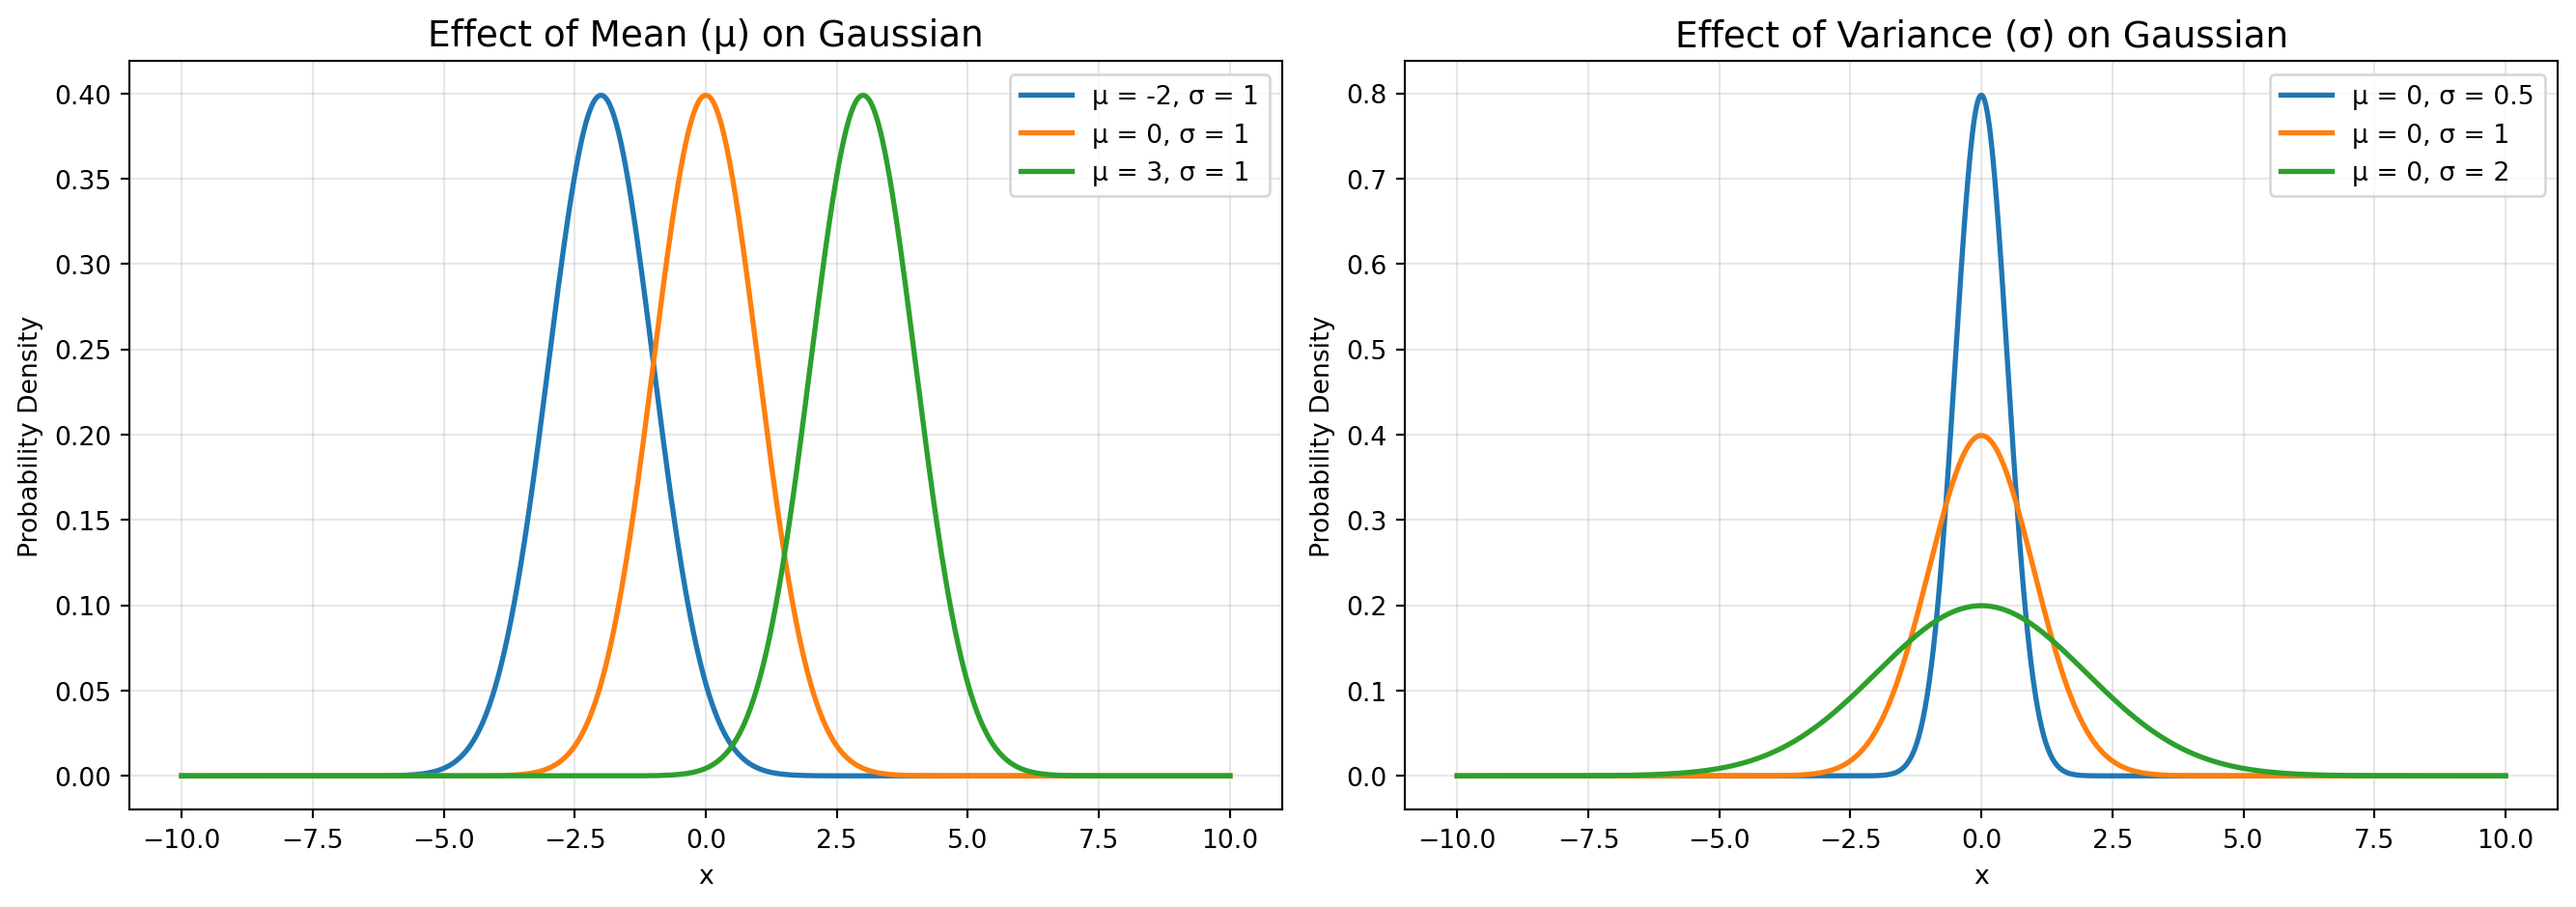

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-10, 10, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Effect of different means (same variance)
ax1 = axes[0]
for mu in [-2, 0, 3]:
    y = norm.pdf(x, mu, 1)
    ax1.plot(x, y, linewidth=2, label=f'μ = {mu}, σ = 1')
ax1.set_title('Effect of Mean (μ) on Gaussian', fontsize=14)
ax1.set_xlabel('x')
ax1.set_ylabel('Probability Density')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Effect of different variances (same mean)
ax2 = axes[1]
for sigma in [0.5, 1, 2]:
    y = norm.pdf(x, 0, sigma)
    ax2.plot(x, y, linewidth=2, label=f'μ = 0, σ = {sigma}')
ax2.set_title('Effect of Variance (σ) on Gaussian', fontsize=14)
ax2.set_xlabel('x')
ax2.set_ylabel('Probability Density')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

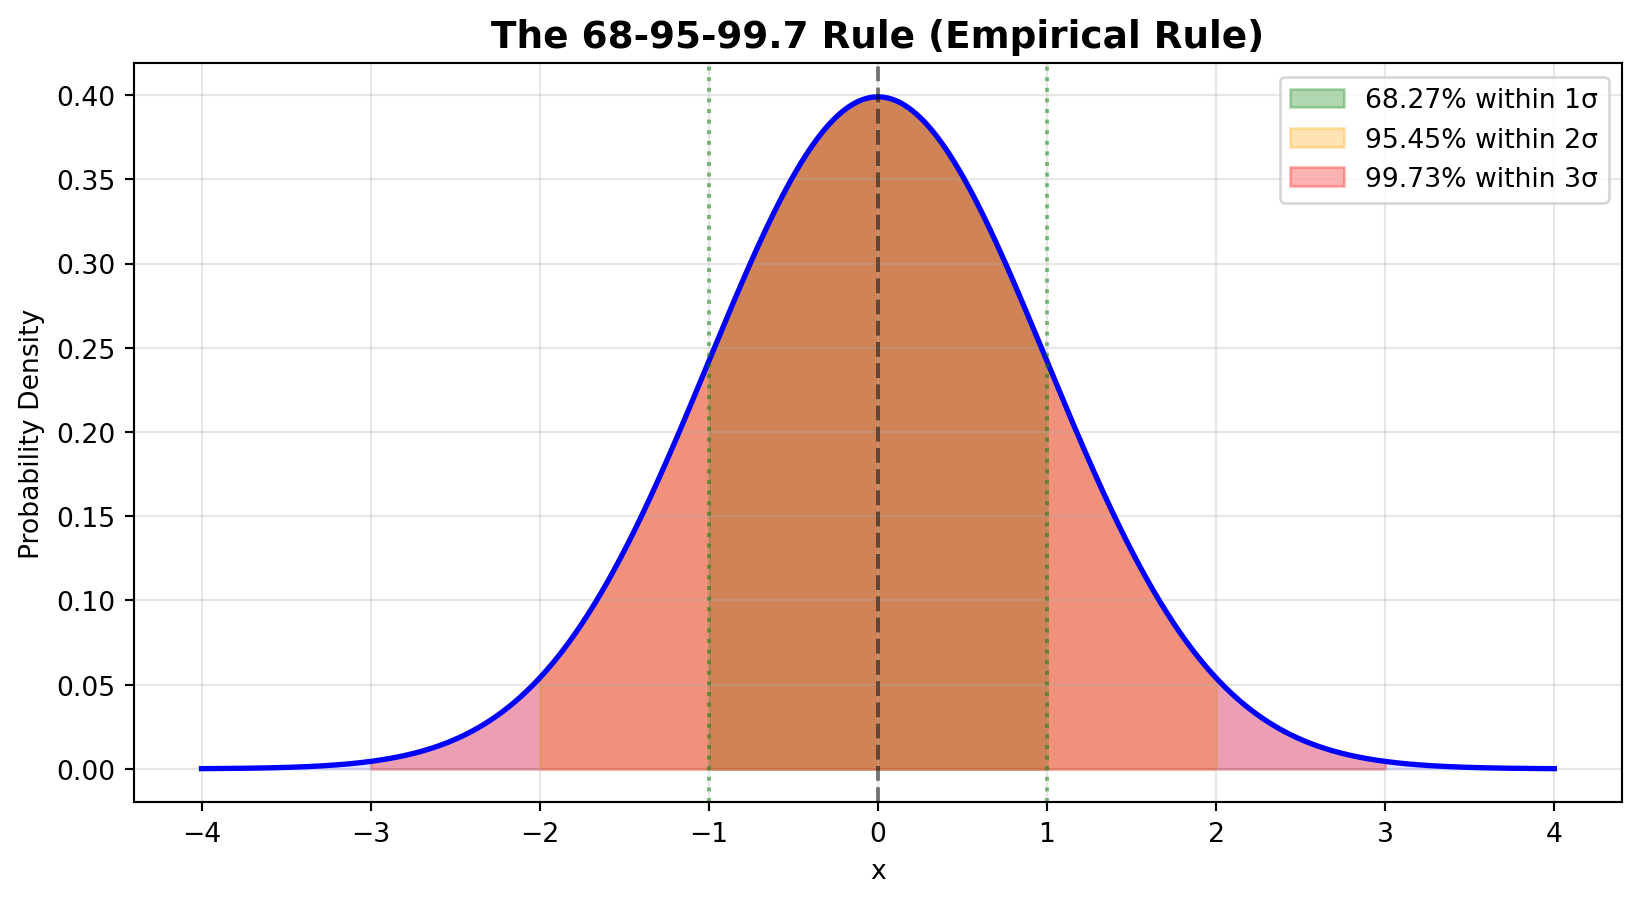

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, 'b-', linewidth=2)
ax.fill_between(x, y, alpha=0.1, color='blue')

# 68% region
x1 = np.linspace(mu - sigma, mu + sigma, 100)
y1 = norm.pdf(x1, mu, sigma)
ax.fill_between(x1, y1, alpha=0.3, color='green', label='68.27% within 1σ')

# 95% region
x2 = np.linspace(mu - 2*sigma, mu + 2*sigma, 100)
y2 = norm.pdf(x2, mu, sigma)
ax.fill_between(x2, y2, alpha=0.3, color='orange', label='95.45% within 2σ')

# 99.7% region
x3 = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
y3 = norm.pdf(x3, mu, sigma)
ax.fill_between(x3, y3, alpha=0.3, color='red', label='99.73% within 3σ')

ax.axvline(mu, color='black', linestyle='--', alpha=0.5)
ax.axvline(mu + sigma, color='green', linestyle=':', alpha=0.5)
ax.axvline(mu - sigma, color='green', linestyle=':', alpha=0.5)

ax.set_title('The 68-95-99.7 Rule (Empirical Rule)', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('Probability Density')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.show()

Model Comparison Statistics
Model A: Mean = 0.8490, Std = 0.0114
Model B: Mean = 0.8710, Std = 0.0114
Difference: 0.0220

t-statistic: -4.1090
p-value: 0.000329

✓ Statistically significant! (p < 0.05)
Model B is significantly better than Model A.


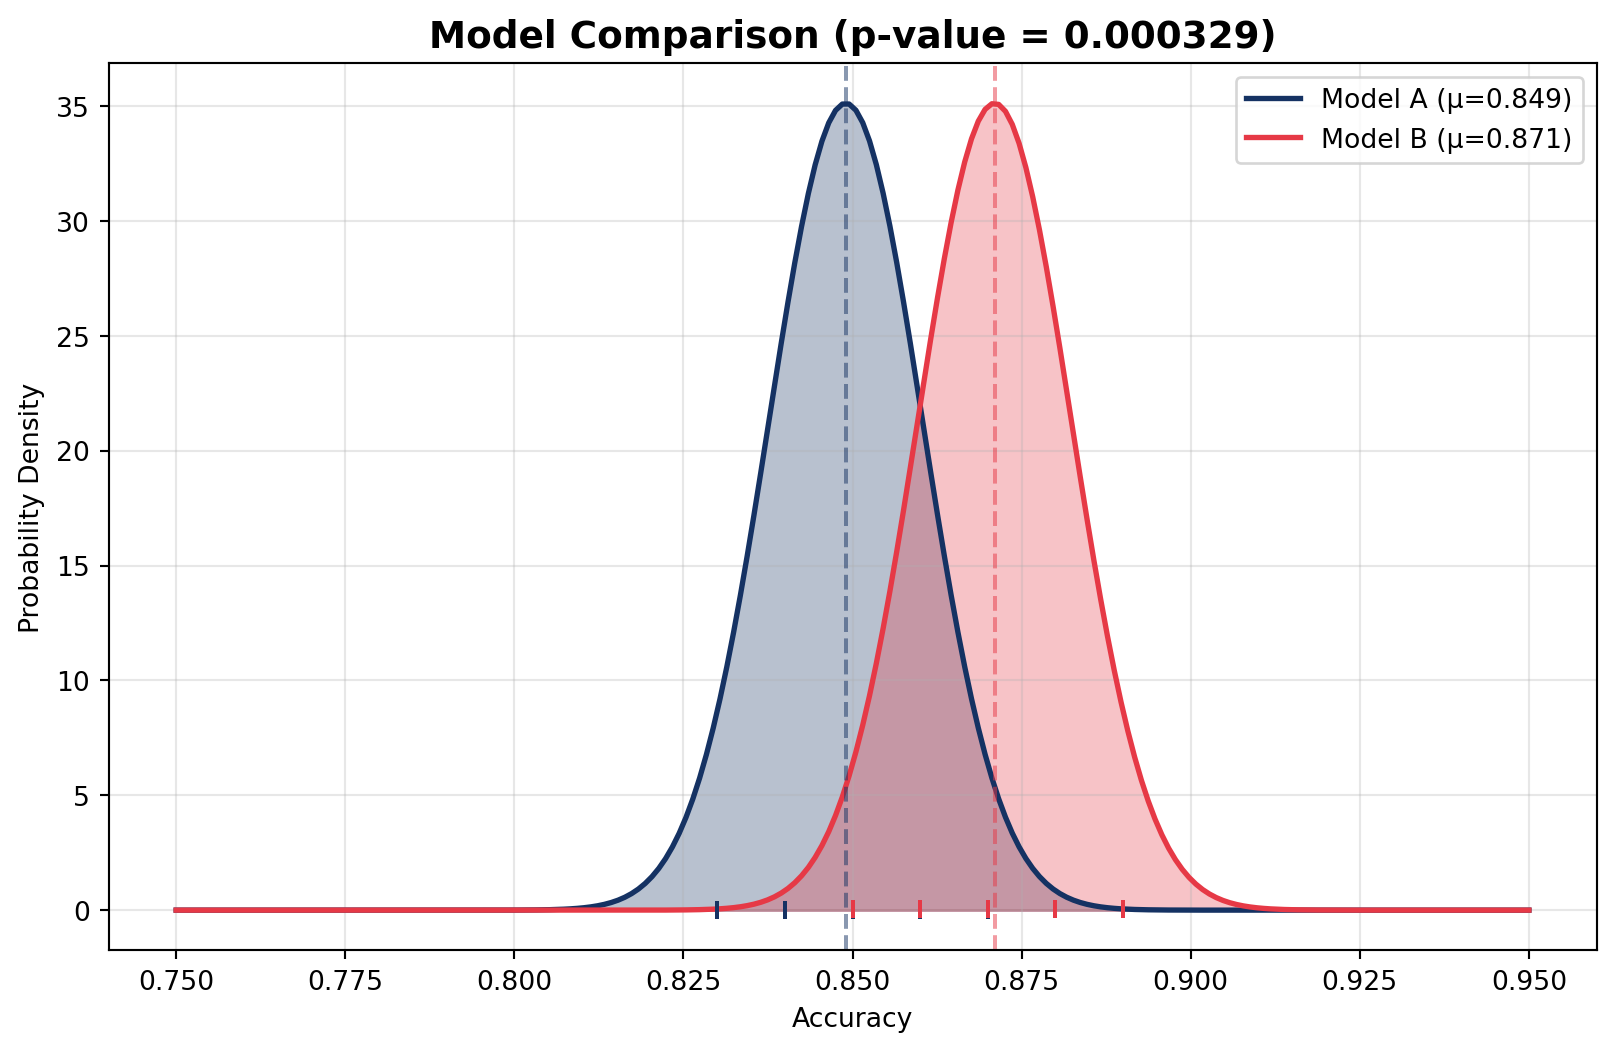

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, ttest_ind

# Simulated cross-validation accuracy data
np.random.seed(42)

# Model A: 10-fold cross-validation accuracies
acc_A = np.array([0.84, 0.86, 0.83, 0.85, 0.87, 0.84, 0.85, 0.86, 0.84, 0.85])

# Model B: 10-fold cross-validation accuracies
acc_B = np.array([0.87, 0.88, 0.85, 0.89, 0.86, 0.88, 0.87, 0.86, 0.88, 0.87])

mean_A, std_A = np.mean(acc_A), np.std(acc_A)
mean_B, std_B = np.mean(acc_B), np.std(acc_B)

print("Model Comparison Statistics")
print("=" * 50)
print(f"Model A: Mean = {mean_A:.4f}, Std = {std_A:.4f}")
print(f"Model B: Mean = {mean_B:.4f}, Std = {std_B:.4f}")
print(f"Difference: {mean_B - mean_A:.4f}")

# Perform t-test
t_stat, p_value = ttest_ind(acc_A, acc_B, alternative='less')  # One-tailed: is B > A?
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print(f"\n✓ Statistically significant! (p < 0.05)")
    print("Model B is significantly better than Model A.")
else:
    print(f"\n✗ Not statistically significant (p >= 0.05)")
    print("Cannot conclude Model B is better.")

# Visualization
x = np.linspace(0.75, 0.95, 200)

fig, ax = plt.subplots(figsize=(10, 6))

y_A = norm.pdf(x, mean_A, std_A)
y_B = norm.pdf(x, mean_B, std_B)

ax.plot(x, y_A, color='#153263', linewidth=2, label=f'Model A (μ={mean_A:.3f})')
ax.fill_between(x, y_A, alpha=0.3, color='#153263')

ax.plot(x, y_B, color='#e63946', linewidth=2, label=f'Model B (μ={mean_B:.3f})')
ax.fill_between(x, y_B, alpha=0.3, color='#e63946')

ax.axvline(mean_A, color='#153263', linestyle='--', alpha=0.5)
ax.axvline(mean_B, color='#e63946', linestyle='--', alpha=0.5)

# Add individual CV scores
ax.scatter(acc_A, np.zeros_like(acc_A) + 0.02, color='#153263', s=50, zorder=5, marker='|')
ax.scatter(acc_B, np.zeros_like(acc_B) + 0.04, color='#e63946', s=50, zorder=5, marker='|')

ax.set_title(f'Model Comparison (p-value = {p_value:.6f})', fontsize=14, fontweight='bold')
ax.set_xlabel('Accuracy')
ax.set_ylabel('Probability Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [18]:
import numpy as np
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
print("A @ B =", A @ B)

A @ B = [[19 22]
 [43 50]]


In [19]:
import numpy as np
T = np.array([[0, -1], [1, 0]])
v = np.array([3, 4])
print("Tv =", T @ v)
print("T²v =", T @ T @ v)
print("T⁴v =", T @ T @ T @ T @ v)
print("T⁴ =", T @ T @ T @ T)

Tv = [-4  3]
T²v = [-3 -4]
T⁴v = [3 4]
T⁴ = [[1 0]
 [0 1]]


In [20]:
import numpy as np
A = np.array([[3, 1], [0, 2]])
eigenvalues, eigenvectors = np.linalg.eig(A)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues: [3. 2.]
Eigenvectors:
 [[ 1.         -0.70710678]
 [ 0.          0.70710678]]


In [21]:
from scipy.stats import norm

mu, sigma = 175, 7

# a) P(X > 182)
p_a = 1 - norm.cdf(182, mu, sigma)
print(f"a) P(X > 182) = {p_a:.4f} ({p_a*100:.2f}%)")

# b) P(168 < X < 182)
p_b = norm.cdf(182, mu, sigma) - norm.cdf(168, mu, sigma)
print(f"b) P(168 < X < 182) = {p_b:.4f} ({p_b*100:.2f}%)")

# c) 95th percentile
height_95 = norm.ppf(0.95, mu, sigma)
print(f"c) 95th percentile height = {height_95:.2f} cm")

a) P(X > 182) = 0.1587 (15.87%)
b) P(168 < X < 182) = 0.6827 (68.27%)
c) 95th percentile height = 186.51 cm


In [22]:
import numpy as np

# Data matrix
X = np.array([[1, 2], [2, 1], [3, 4], [4, 3]])

# a) Center the data
mean = X.mean(axis=0)
X_centered = X - mean
print("Mean:", mean)
print("Centered X:\n", X_centered)

# b) Covariance matrix
cov_matrix = np.cov(X_centered.T)
print("\nCovariance matrix:\n", cov_matrix)

# c) Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("\nEigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

# d) First principal component and variance explained
idx = eigenvalues.argsort()[::-1]
first_pc = eigenvectors[:, idx[0]]
variance_explained = eigenvalues[idx[0]] / eigenvalues.sum()
print(f"\nFirst PC: {first_pc}")
print(f"Variance explained: {variance_explained*100:.2f}%")

Mean: [2.5 2.5]
Centered X:
 [[-1.5 -0.5]
 [-0.5 -1.5]
 [ 0.5  1.5]
 [ 1.5  0.5]]

Covariance matrix:
 [[1.66666667 1.        ]
 [1.         1.66666667]]

Eigenvalues: [2.66666667 0.66666667]
Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

First PC: [0.70710678 0.70710678]
Variance explained: 80.00%


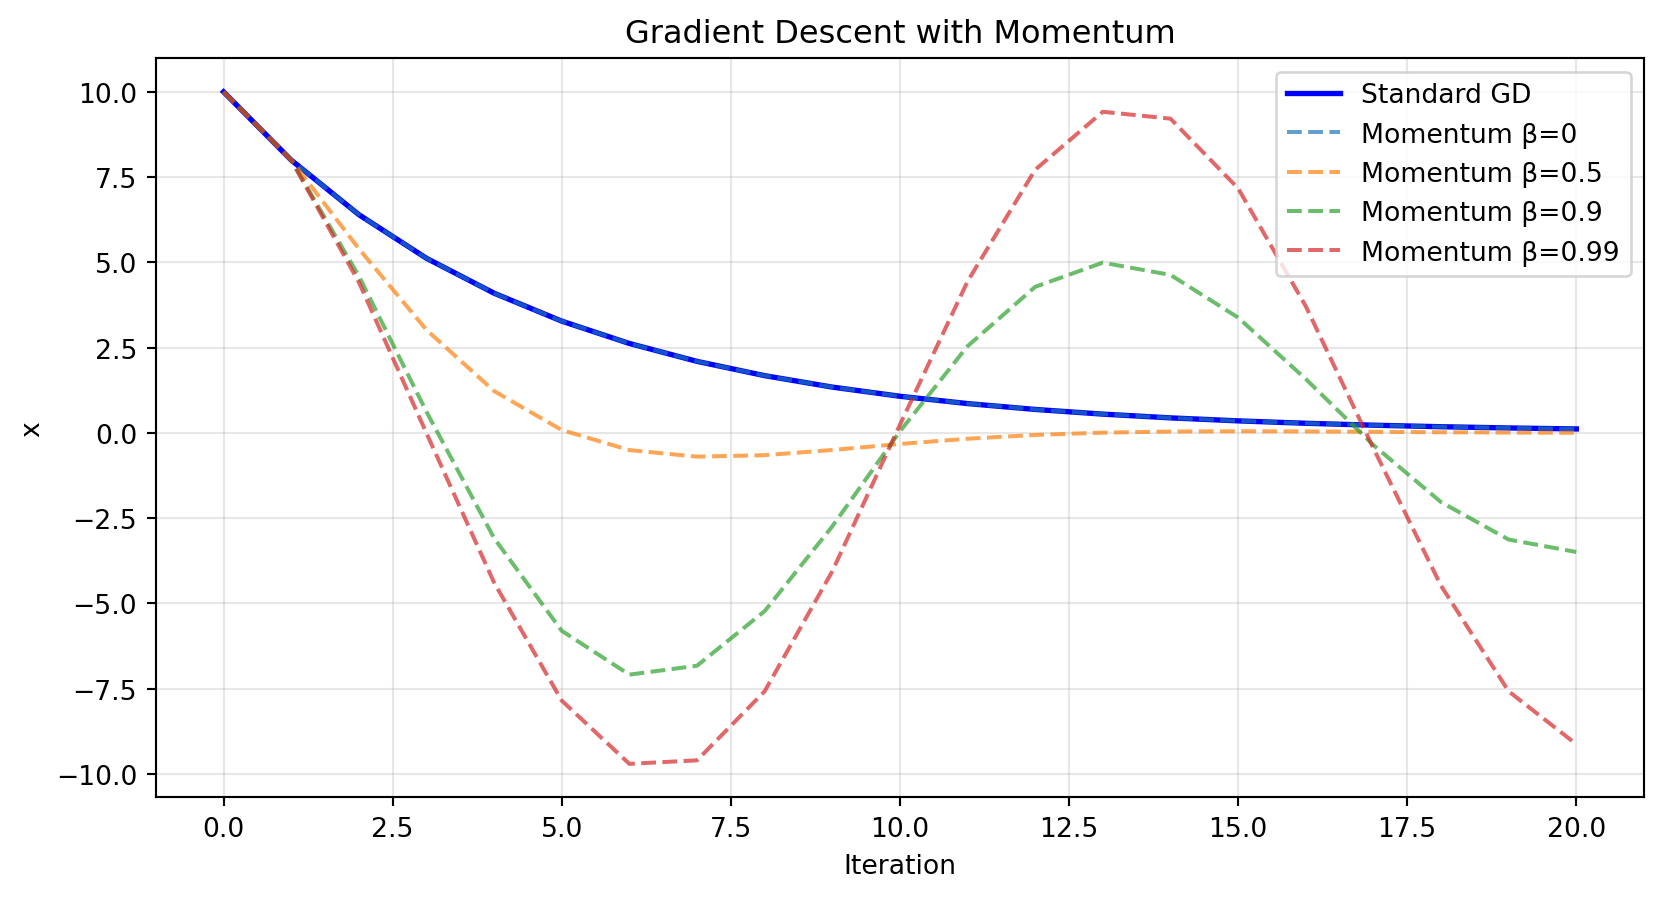

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2

def grad_f(x):
    return 2*x

# Standard GD
def standard_gd(x0, alpha, epochs):
    x = x0
    history = [x]
    for _ in range(epochs):
        x = x - alpha * grad_f(x)
        history.append(x)
    return history

# GD with momentum
def momentum_gd(x0, alpha, beta, epochs):
    x = x0
    v = 0
    history = [x]
    for _ in range(epochs):
        v = beta * v + alpha * grad_f(x)
        x = x - v
        history.append(x)
    return history

# Compare
x0 = 10
alpha = 0.1
epochs = 20

std_history = standard_gd(x0, alpha, epochs)
moments = [0, 0.5, 0.9, 0.99]

plt.figure(figsize=(10, 5))
plt.plot(range(len(std_history)), std_history, 'b-', label='Standard GD', linewidth=2)

for beta in moments:
    mom_history = momentum_gd(x0, alpha, beta, epochs)
    plt.plot(range(len(mom_history)), mom_history, '--', label=f'Momentum β={beta}', alpha=0.7)

plt.xlabel('Iteration')
plt.ylabel('x')
plt.title('Gradient Descent with Momentum')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
import numpy as np
from scipy.stats import norm

# Generate data from known distribution
np.random.seed(42)
true_mu, true_sigma = 5.0, 2.0
data = np.random.normal(true_mu, true_sigma, 1000)

# MLE estimates
mu_mle = np.mean(data)
sigma2_mle = np.var(data)  # MLE uses n, not n-1

print(f"True μ = {true_mu}, MLE μ̂ = {mu_mle:.4f}")
print(f"True σ = {true_sigma}, MLE σ̂ = {np.sqrt(sigma2_mle):.4f}")

# The MLE for μ is the sample mean
# The MLE for σ² is the sample variance (with n, not n-1)

True μ = 5.0, MLE μ̂ = 5.0387
True σ = 2.0, MLE σ̂ = 1.9575
